# Vision Transformer (ViT) on CIFAR-10 — A Complete Research-Grade Walkthrough

## Section 1: Project Introduction

### What is Image Classification?
Image classification is the task of assigning a single label (class) to an entire input image
from a fixed set of categories. Formally, given an image $x \in \mathbb{R}^{H \times W \times C}$
(height, width, channels) and a set of classes $\{1, 2, \dots, K\}$, we want to learn a function
$f_\theta(x) \rightarrow y \in \{1, \dots, K\}$ parameterized by weights $\theta$ that generalizes
well to unseen images.

### What is CIFAR-10?
CIFAR-10 is a benchmark dataset consisting of 60,000 32x32 color images in 10 classes
(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), with 6,000 images per
class. It is split into 50,000 training images and 10,000 test images. Despite its small image
size, CIFAR-10 is non-trivial: low resolution, intra-class variation, and inter-class similarity
(e.g., cat vs dog) make it a meaningful benchmark.

### Why CIFAR-10 is Important
- Small enough to train quickly on a single GPU/CPU, ideal for educational purposes.
- Large and diverse enough to meaningfully evaluate architectural choices.
- Widely used in literature, enabling direct comparison with published baselines.

### What are Transformers?
Transformers are a neural network architecture introduced in *"Attention Is All You Need"*
(Vaswani et al., 2017), originally for NLP. Their core building block is **self-attention**,
which lets every element of a sequence directly attend to every other element, regardless of
distance, without the sequential recurrence of RNNs or the limited receptive field of a single
convolution.

### Why Vision Transformers (ViT) Were Created
Convolutional Neural Networks (CNNs) build in a strong **inductive bias**: locality (nearby
pixels are related) and translation invariance (a filter detects the same feature anywhere in
the image). This bias is helpful with limited data but can also limit what the model can learn.
Dosovitskiy et al. (2020) proposed treating an image as a **sequence of patches** and feeding it
directly into a standard Transformer encoder, asking: *can a model with far less built-in visual
bias, given enough data, match or exceed CNNs?* The answer, especially at scale, was yes.

### CNN vs Vision Transformer

| Aspect | CNN | ViT |
|---|---|---|
| Inductive bias | Strong (locality, weight sharing) | Weak (treats patches as a set/sequence) |
| Receptive field | Grows gradually with depth | Global from layer 1 (full self-attention) |
| Data efficiency | Good on small datasets | Needs more data or augmentation/pretraining |
| Parallelism | Convolutions are local but sequential in depth | Highly parallel attention computation |
| Interpretability | Saliency/Grad-CAM | Native attention maps |

### Advantages of ViT
- Global context modeling from the very first layer.
- Scales extremely well with more data and compute.
- Simple, uniform architecture (mostly matrix multiplications), good hardware utilization.

### Disadvantages of ViT
- Quadratic compute/memory in the number of patches ($O(N^2)$ for $N$ patches).
- Weaker inductive bias means it can underperform CNNs on small datasets without heavy
  augmentation, regularization, or pretraining.
- Less sample-efficient than CNNs when training from scratch on small data like CIFAR-10.

We will visualize the CNN vs ViT receptive-field difference conceptually below.

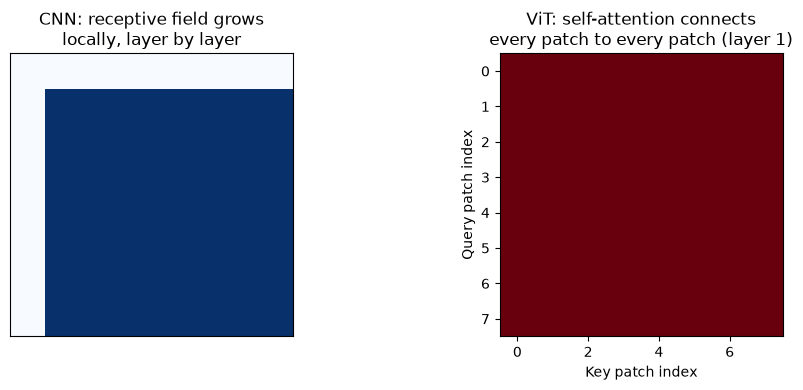

In [5]:
# We build a simple conceptual diagram contrasting how a CNN's receptive field grows
# locally with depth versus how a ViT attends globally from the very first layer.
import matplotlib.pyplot as plt   # plotting library used throughout the notebook
import numpy as np                # numerical computing library for array operations
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # one row, two side-by-side plots
# --- Left plot: CNN receptive field growing layer by layer (concentric squares) ---
ax = axes[0]
grid = np.zeros((8, 8))                    # an 8x8 "image" grid of zeros (background)
center = (4, 4)                            # the pixel whose receptive field we are growing
for layer, size in enumerate([1, 3, 5, 7]):    # receptive field radius grows with depth
    half = size // 2
    grid[center[0]-half:center[0]+half+1, center[1]-half:center[1]+half+1] = layer + 1
ax.imshow(grid, cmap="Blues")              # darker blue = deeper layer's receptive field
ax.set_title("CNN: receptive field grows\nlocally, layer by layer")
ax.set_xticks([]); ax.set_yticks([])       # hide axis ticks, this is a schematic not real data
# --- Right plot: ViT attention is global immediately (every patch connects to every patch) ---
ax = axes[1]
n_patches = 8                              # imagine an 8-patch sequence for illustration
grid2 = np.ones((n_patches, n_patches))    # every patch attends to every other patch (all 1s)
ax.imshow(grid2, cmap="Reds", vmin=0, vmax=1)
ax.set_title("ViT: self-attention connects\nevery patch to every patch (layer 1)")
ax.set_xlabel("Key patch index"); ax.set_ylabel("Query patch index")
plt.tight_layout()                         # avoid overlapping titles/labels
plt.show()                                 # render the figure inline

**Explanation of result:** The left panel shows how a CNN's receptive field (the region of
the input that influences a given output unit) expands gradually as we stack more convolutional
layers — information takes several layers to mix information of pixels far apart spatially. The
right panel shows that in a single self-attention layer, every patch (query) can directly attend
to every other patch (key) — the "receptive field" is global immediately. This is the foundational
difference that motivates the entire ViT architecture.

**Next step:** We will set up our Python environment and import every library we need, with a
short explanation of each.

## Section 2: Environment Setup

### What We Will Do
Import all the libraries this project depends on: PyTorch for tensors/autograd/neural networks,
torchvision for the CIFAR-10 dataset and image transforms, numpy/pandas for numerical and
tabular data handling, matplotlib/seaborn for visualization, scikit-learn for classical ML
metrics (confusion matrix, ROC, PCA, t-SNE), tqdm for progress bars, torchinfo for clean model
summaries, and einops for readable tensor reshaping (used heavily inside ViT).

### Why We Are Doing It
Having every import in one place at the top makes the rest of the notebook's code cells small
and focused (per the project's rule of no monolithic cells), and documents exactly what
machinery the project depends on.

### Expected Outcome
All libraries import without error and we print their versions for reproducibility records.

### Practical Importance
Recording library versions is a research best-practice: it lets others (or future-you)
reproduce your exact environment.

In [6]:
# If a library is missing in your environment, uncomment the relevant pip install line below.
# %pip install torch torchvision numpy pandas matplotlib seaborn scikit-learn tqdm torchinfo einops

import os
# On Windows, PyTorch's bundled Intel OpenMP runtime can collide with the OpenMP runtime that
# numpy/scikit-learn also load, which silently crashes the whole Jupyter kernel (no Python
# traceback) the moment both get initialized in the same process. Setting this BEFORE any of
# those libraries are imported tells the runtime to tolerate the duplicate instead of aborting.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings                       # used to silence noisy, non-critical warnings
warnings.filterwarnings("ignore")     # keeps notebook output clean for readability
import torch                          # core PyTorch: tensors, autograd, device management
import torch.nn as nn                 # neural network building blocks (Linear, LayerNorm, etc.)
import torch.nn.functional as F       # functional ops (softmax, cross_entropy, gelu, etc.)
from torch.utils.data import DataLoader, random_split  # batching/iterating datasets
import torchvision                              # vision-specific datasets and utilities
import torchvision.transforms as T               # image preprocessing/augmentation pipelines
from torchvision.datasets import CIFAR10         # the CIFAR-10 dataset loader itself
import numpy as np                    # numerical arrays, used for stats and plotting prep
import pandas as pd                   # tabular data (e.g., class distribution tables)
import matplotlib.pyplot as plt       # primary plotting library
import seaborn as sns                 # statistical plotting (heatmaps, KDE, violin plots)
from sklearn.metrics import (         # classical ML evaluation utilities
    confusion_matrix, classification_report, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve, top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize  # one-hot encode labels for multi-class ROC
from sklearn.decomposition import PCA              # dimensionality reduction for feature analysis
from sklearn.manifold import TSNE                  # nonlinear dimensionality reduction
from tqdm.auto import tqdm            # progress bars that work in both notebook and terminal
from torchinfo import summary         # prints a clean, Keras-style model summary
from einops import rearrange          # readable, named-axis tensor reshaping (used inside ViT)
import time                           # for timing inference / training speed
import math                           # math.sqrt, math.pi etc. used in attention scaling
print("torch       :", torch.__version__)        # record exact versions for reproducibility
print("torchvision :", torchvision.__version__)
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)

torch       : 2.5.1+cu121
torchvision : 0.20.1+cu121
numpy       : 2.4.4
pandas      : 3.0.3


**Explanation of result:** Printing the versions confirms every dependency imported
successfully and gives us a reproducibility record — if results differ on another machine, this
is the first thing to compare.

**Next step:** We fix random seeds and select a compute device (GPU if available, else CPU) so
that every later experiment is reproducible and device-agnostic.

In [7]:
# Reproducibility: fixing seeds makes weight initialization, shuffling, and augmentation
# deterministic across runs, which is essential for fair comparisons in later sections.
SEED = 42                              # arbitrary but fixed seed value
torch.manual_seed(SEED)                # seeds CPU random number generator used by PyTorch
np.random.seed(SEED)                   # seeds numpy's RNG (used by sklearn, augmentations)
# Device-agnostic code: prefer GPU (CUDA) if available, otherwise fall back to CPU.
# This single 'device' variable is reused everywhere so the notebook runs unmodified on any machine.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():                                  # only query GPU info if present
    print("GPU name:", torch.cuda.get_device_name(0))           # human-readable GPU name
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory (GB): 4.29


**Explanation of result:** We now have a fixed seed for reproducible randomness and a
`device` variable that the rest of the notebook will use for `.to(device)` calls, making all code
run unchanged whether a GPU is present or not.

**Next step:** Load and explore the raw CIFAR-10 dataset: how many samples, what the classes are,
and whether classes are balanced.

## Section 3: Understanding the CIFAR-10 Dataset

### What We Will Do
Download (if not already cached) and load the CIFAR-10 train and test sets, inspect their
sizes, list the class names, and check the class distribution.

### Why We Are Doing It
Before modeling, we must understand our data: how many samples we have, whether classes are
balanced (an imbalanced dataset would require special handling like weighted loss), and what
the raw image format looks like.

### Expected Outcome
50,000 training images and 10,000 test images, 10 classes, perfectly balanced (6,000 train / 600
test images per class — CIFAR-10 is balanced by design).

### Theory Behind It
A balanced dataset means accuracy is a meaningful metric on its own; with imbalance we'd lean
more on macro-F1 or per-class recall.

In [8]:
# torchvision.datasets.CIFAR10 automatically downloads the dataset (if not cached locally)
# and exposes it as a list-like object of (PIL_image, integer_label) pairs.
train_raw = CIFAR10(root="./data", train=True, download=True)   # 50,000 training images
test_raw  = CIFAR10(root="./data", train=False, download=True)  # 10,000 test images
class_names = train_raw.classes        # e.g. ['airplane', 'automobile', 'bird', ...]
print("Number of training images:", len(train_raw))
print("Number of test images    :", len(test_raw))
print("Number of classes        :", len(class_names))
print("Class names               :", class_names)
print("Raw image type            :", type(train_raw[0][0]), "size:", train_raw[0][0].size)

Files already downloaded and verified
Files already downloaded and verified
Number of training images: 50000
Number of test images    : 10000
Number of classes        : 10
Class names               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Raw image type            : <class 'PIL.Image.Image'> size: (32, 32)


In [9]:
# Compute the class distribution (how many images belong to each class) for train and test.
train_labels = np.array(train_raw.targets)   # list of integer labels -> numpy array for fast counting
test_labels  = np.array(test_raw.targets)
train_counts = pd.Series(train_labels).value_counts().sort_index()   # count per class index
test_counts  = pd.Series(test_labels).value_counts().sort_index()
dist_table = pd.DataFrame({                      # build a readable frequency table
    "class": class_names,
    "train_count": train_counts.values,
    "test_count": test_counts.values
})
dist_table

,class,train_count,test_count
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


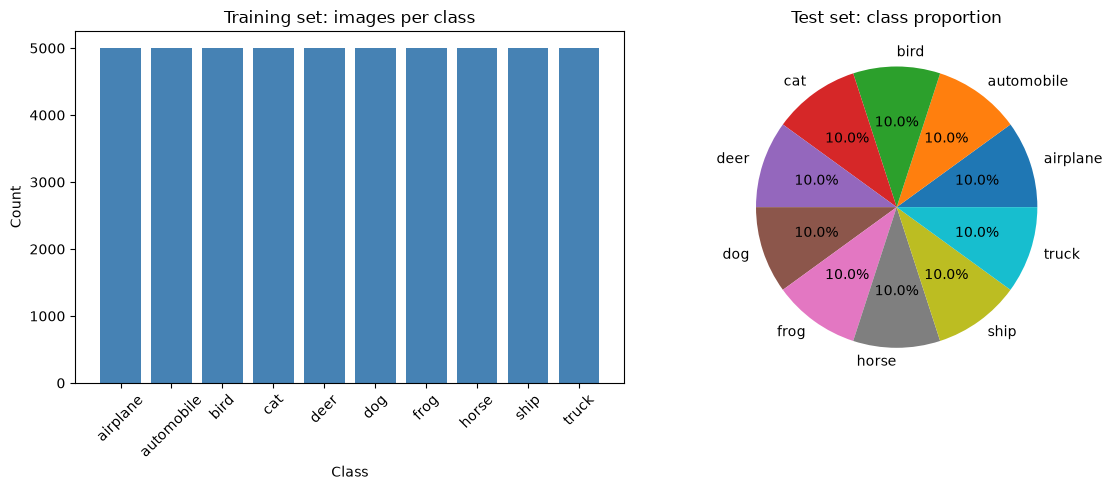

In [10]:
# Visualize the class distribution with a bar chart (train) and a pie chart (test),
# confirming visually that CIFAR-10 is perfectly balanced across all 10 classes.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(dist_table["class"], dist_table["train_count"], color="steelblue")  # bar per class
axes[0].set_title("Training set: images per class")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)        # rotate labels so they don't overlap
axes[1].pie(dist_table["test_count"], labels=dist_table["class"], autopct="%1.1f%%")  # share per class
axes[1].set_title("Test set: class proportion")
plt.tight_layout()
plt.show()

**Explanation of findings:** Every bar in the left chart is exactly the same height (6,000)
and every pie slice is exactly 10% — CIFAR-10 is perfectly class-balanced, so plain accuracy will
be a fair and sufficient primary metric (we will still track macro-F1 for extra rigor later).

**Next step:** Visualize actual images — random samples and class-wise grids — to build visual
intuition for how hard this classification problem is.

## Section 4: Data Visualization

### What We Will Do
Display random sample images, a grid of one example per class, and analyze pixel-level
statistics (RGB channel distributions).

### Why We Are Doing It
Looking at real images grounds our understanding: CIFAR-10 images are tiny (32x32), often
blurry, and some classes (cat/dog, automobile/truck) are visually similar — this explains why the
task isn't trivial despite being a "small" benchmark.

### Theory Behind It
Each image is stored as `H x W x C = 32 x 32 x 3` (RGB), with pixel intensities in `[0, 255]`.
Understanding the raw pixel distribution motivates the normalization step in Section 5.

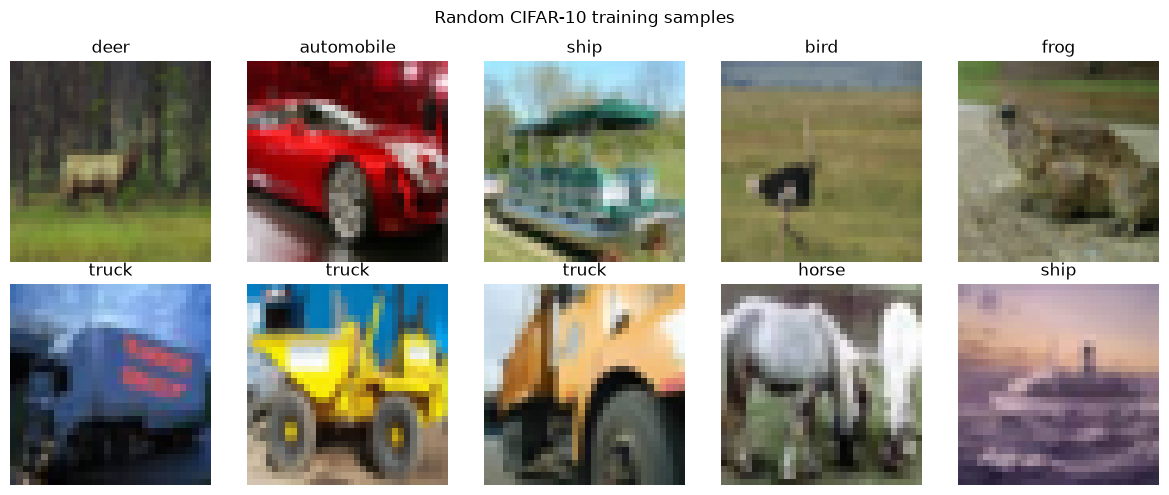

In [11]:
# Display 10 random images from the training set with their class labels as titles.
rng = np.random.default_rng(SEED)                  # local numpy RNG, seeded for reproducibility
idxs = rng.choice(len(train_raw), size=10, replace=False)  # pick 10 distinct random indices
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), idxs):
    img, label = train_raw[idx]                     # PIL image, integer label
    ax.imshow(img)                                   # render the RGB image
    ax.set_title(class_names[label])                 # show the human-readable class name
    ax.axis("off")                                    # hide axis ticks for a cleaner look
plt.suptitle("Random CIFAR-10 training samples")
plt.tight_layout()
plt.show()

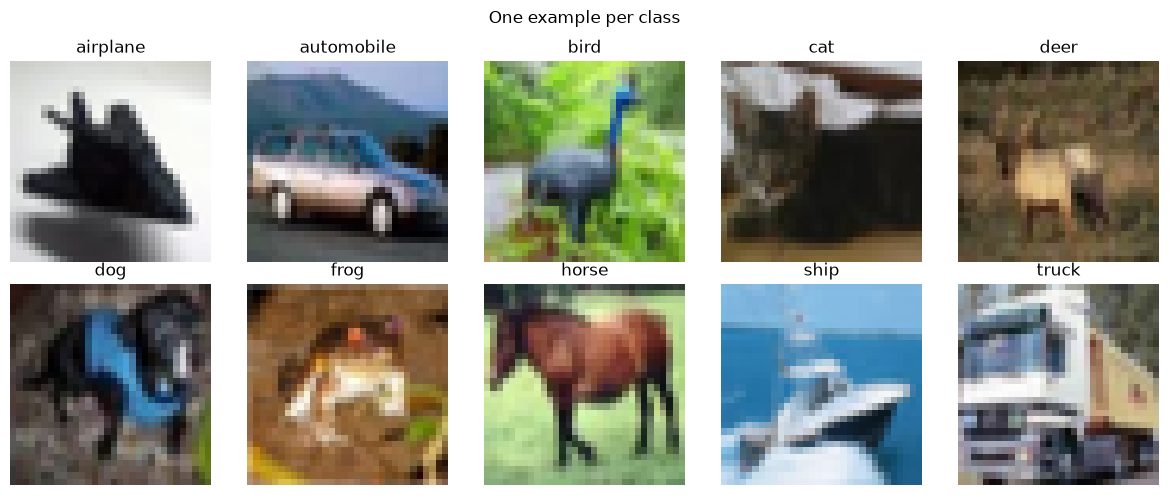

In [12]:
# Build a grid showing one example image per class, to compare classes side by side.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for class_idx, ax in enumerate(axes.flatten()):
    # find the first training image whose label matches this class index
    sample_idx = int(np.where(train_labels == class_idx)[0][0])
    img, _ = train_raw[sample_idx]
    ax.imshow(img)
    ax.set_title(class_names[class_idx])
    ax.axis("off")
plt.suptitle("One example per class")
plt.tight_layout()
plt.show()

Sample batch shape (N, H, W, C): (10, 32, 32, 3)
Pixel value range: min = 0  max = 255


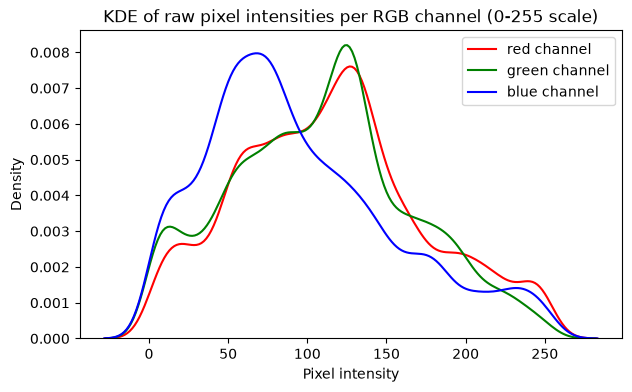

In [13]:
# Analyze pixel-level statistics: convert a sample of images to numpy and look at the
# distribution of pixel intensities per RGB channel (before any normalization).
sample_imgs = np.stack([np.array(train_raw[i][0]) for i in idxs])   # shape: (10, 32, 32, 3)
print("Sample batch shape (N, H, W, C):", sample_imgs.shape)
print("Pixel value range: min =", sample_imgs.min(), " max =", sample_imgs.max())
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["red", "green", "blue"]
for c, color in enumerate(colors):
    sns.kdeplot(sample_imgs[..., c].flatten(), color=color, label=f"{color} channel", ax=ax)
ax.set_title("KDE of raw pixel intensities per RGB channel (0-255 scale)")
ax.set_xlabel("Pixel intensity"); ax.set_ylabel("Density")
ax.legend()
plt.show()

**Insights:** Raw pixel values span the full `[0, 255]` range and the three channels have
broadly similar but not identical distributions (natural images tend to have slightly more
energy in certain channels depending on scene content — e.g. more "sky blue" or "green foliage").
This raw, unnormalized, large-magnitude input is poorly suited for gradient-based optimization —
motivating the normalization step next.

**Next step:** Preprocess the data — convert to tensors, normalize, and apply data augmentation
— with visual before/after comparisons.

## Section 5: Data Preprocessing

### What We Will Do
Define two `torchvision.transforms` pipelines: a training pipeline (with augmentation) and a
test/validation pipeline (deterministic, no augmentation), then visualize their effect.

### Why We Are Doing It
Neural networks train faster and more stably on normalized inputs (mean 0, unit variance), and
data augmentation (random crops/flips) acts as a regularizer, artificially increasing the
diversity of the training set and reducing overfitting — especially important for ViT, which has
a weaker inductive bias than CNNs and is more prone to overfitting on a small dataset like
CIFAR-10.

### Mathematical Formula for Normalization
For each channel $c$, every pixel value $x$ is transformed as:

$$x'_c = \frac{x_c - \mu_c}{\sigma_c}$$

where $\mu_c$ and $\sigma_c$ are the per-channel mean and standard deviation computed over the
training set (here we use the well-known CIFAR-10 statistics).

### Expected Outcome
Pixel values centered near 0 with most values in roughly $[-2, 2]$, and visibly augmented
(flipped/cropped) training images.

In [14]:
# CIFAR-10 per-channel mean/std (commonly used published statistics), computed over the
# training set in [0, 1] scale. Using known constants avoids recomputing them each run.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
# Training transform: augmentation (crop + flip) followed by tensor conversion and normalization.
train_transform = T.Compose([
    T.RandomCrop(32, padding=4),        # randomly crop a 32x32 region from a zero-padded image
                                          # -> teaches translation invariance, reduces overfitting
    T.RandomHorizontalFlip(p=0.5),       # mirror the image left-right with 50% probability
                                          # -> valid for CIFAR-10 since flipped objects are still
                                          #    the same class (a flipped cat is still a cat)
    T.ToTensor(),                        # converts PIL image (H,W,C, 0-255) to tensor (C,H,W, 0-1)
    T.Normalize(CIFAR_MEAN, CIFAR_STD)   # applies x' = (x - mean) / std per channel
])
# Test transform: NO augmentation (we want deterministic, reproducible evaluation),
# only the same normalization used at training time.
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD)
])
print("Train transform:", train_transform)
print("Test transform :", test_transform)

Train transform: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
Test transform : Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


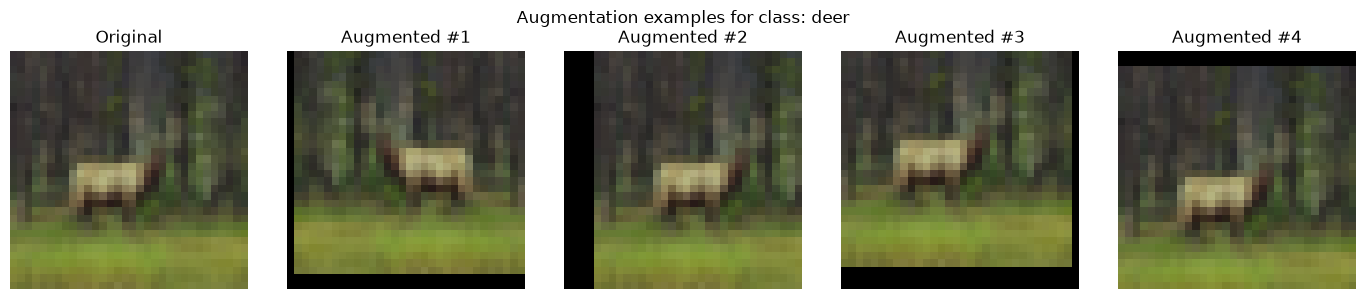

In [15]:
# Visualize the effect of augmentation: same source image, multiple augmented versions.
sample_img, sample_label = train_raw[idxs[0]]   # reuse one of our earlier random samples
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 5):
    augmented = train_transform(sample_img)             # apply random crop+flip+normalize
    # unnormalize back to [0,1] for display purposes only (visualization, not training data)
    unnorm = augmented * torch.tensor(CIFAR_STD).view(3,1,1) + torch.tensor(CIFAR_MEAN).view(3,1,1)
    axes[i].imshow(unnorm.permute(1, 2, 0).clamp(0, 1).numpy())  # CxHxW -> HxWxC for matplotlib
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")
plt.suptitle(f"Augmentation examples for class: {class_names[sample_label]}")
plt.tight_layout()
plt.show()

**Explanation of result:** Each "Augmented" panel is a different random crop/flip of the
same source image — the object is still recognizable (same label), but the model sees slightly
different pixel arrangements each epoch, which discourages it from memorizing exact pixel
positions.

**Next step:** Wrap these transforms into actual `Dataset` and `DataLoader` objects that can
serve shuffled mini-batches efficiently during training.

## Section 6: DataLoader Creation

### What We Will Do
Wrap the raw CIFAR-10 datasets with our transforms, split a validation set out of the training
data, and build `DataLoader`s for train/val/test.

### Why We Are Doing It
`DataLoader` handles batching, shuffling, and (optionally) parallel data loading via worker
processes — essential for efficient training. A held-out validation split lets us monitor
generalization during training without touching the test set.

### Theory Behind Key Parameters
- **Batch size**: number of samples processed together in one forward/backward pass; affects
  gradient noise and memory usage. We use a moderate value (128) suitable for CPU/GPU.
- **Shuffling**: randomizing sample order each epoch prevents the model from learning spurious
  patterns tied to data ordering.
- **num_workers**: number of background processes that pre-fetch batches in parallel with
  training, overlapping I/O with computation.

In [16]:
# Apply the transform pipelines to torchvision's CIFAR10 dataset class directly
# (CIFAR10 accepts a `transform` argument that is applied lazily, per-sample, on __getitem__).
full_train_ds = CIFAR10(root="./data", train=True, download=False, transform=train_transform)
test_ds       = CIFAR10(root="./data", train=False, download=False, transform=test_transform)
# Carve out 10% of the training set as a validation set, used only for monitoring -- never for
# gradient updates -- so we can detect overfitting before evaluating on the untouched test set.
val_fraction = 0.1
n_val = int(len(full_train_ds) * val_fraction)
n_train = len(full_train_ds) - n_val
train_ds, val_ds = random_split(
    full_train_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)   # seeded split -> reproducible
)
# IMPORTANT: val_ds shares the *training* transform pipeline (with augmentation) because
# random_split wraps the same underlying dataset object. For a clean validation signal we
# instead build a second copy of the dataset with the *test* (non-augmented) transform and
# reuse only the indices chosen by random_split.
val_ds_clean = CIFAR10(root="./data", train=True, download=False, transform=test_transform)
val_ds = torch.utils.data.Subset(val_ds_clean, val_ds.indices)
print("Train size:", len(train_ds), " Val size:", len(val_ds), " Test size:", len(test_ds))

Train size: 45000  Val size: 5000  Test size: 10000


In [17]:
# Build the actual DataLoaders. Note shuffle=True only for training (order shouldn't matter
# for evaluation, and shuffling there would only add overhead).
BATCH_SIZE = 128                      # number of images per mini-batch
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0, pin_memory=torch.cuda.is_available())
# Pull one batch to inspect its tensor structure.
images_batch, labels_batch = next(iter(train_loader))
print("Image batch shape (N, C, H, W):", images_batch.shape)   # e.g. [128, 3, 32, 32]
print("Label batch shape (N,)        :", labels_batch.shape)   # e.g. [128]
print("Image dtype:", images_batch.dtype, " Label dtype:", labels_batch.dtype)

Image batch shape (N, C, H, W): torch.Size([128, 3, 32, 32])
Label batch shape (N,)        : torch.Size([128])
Image dtype: torch.float32  Label dtype: torch.int64


**Explanation of result:** Each batch is a tensor of shape `(N, C, H, W) = (128, 3, 32, 32)`
— PyTorch's convolution/transformer layers expect channels-first format. We now have everything
needed to start describing the ViT architecture itself.

**Next step:** Deep-dive into Vision Transformer theory before writing a single line of model
code.

## Section 7: Vision Transformer Theory (Deep Dive)

### Patch Extraction
ViT does not operate on raw pixels with convolutions. Instead, the image
$x \in \mathbb{R}^{H \times W \times C}$ is split into $N$ non-overlapping square patches of size
$P \times P$:

$$N = \frac{H}{P} \times \frac{W}{P}$$

For CIFAR-10 ($H=W=32$) with patch size $P=4$, we get $N = (32/4)\times(32/4) = 8 \times 8 = 64$
patches, each of shape $4 \times 4 \times 3 = 48$ values when flattened.

### Patch Embedding
Each flattened patch (a vector of size $P^2 C$) is linearly projected into a $D$-dimensional
embedding space via a learned matrix $E \in \mathbb{R}^{(P^2C) \times D}$:

$$z_i = \text{patch}_i \cdot E, \quad i = 1, \dots, N$$

This is mathematically identical to a single convolution with kernel size $P$ and stride $P$ —
in code we actually implement it as `nn.Conv2d` for efficiency, but conceptually it is "flatten +
linear projection."

### Classification Token
A special learnable vector, the `[CLS]` token, is prepended to the sequence of patch embeddings.
After passing through all transformer layers, the `[CLS]` token's final representation is used
for classification — it acts as a learned "summary" that aggregates information from every patch
via self-attention.

### Positional Embedding
Self-attention is permutation-invariant — it has no notion of patch order or position. We add a
learned positional embedding $E_{pos} \in \mathbb{R}^{(N+1) \times D}$ to the patch (+ CLS)
embeddings so the model can use spatial location information:

$$z_0 = [x_{cls}; z_1; z_2; \dots; z_N] + E_{pos}$$

### Multi-Head Self-Attention (MHSA)
For an input sequence $Z \in \mathbb{R}^{(N+1) \times D}$, we compute three learned linear
projections:

$$Q = ZW_Q,\quad K = ZW_K,\quad V = ZW_V$$

**Query (Q)**: "what am I looking for". **Key (K)**: "what do I contain, for others to match
against". **Value (V)**: "what information do I actually provide if attended to".

### Attention Score Calculation & Softmax
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

$QK^T$ computes a similarity score between every pair of tokens (dot product). Dividing by
$\sqrt{d_k}$ (the dimension of each head) prevents the dot products from growing too large in
magnitude, which would push softmax into extremely peaked, low-gradient regions. Softmax
converts each row of scores into a probability distribution over which tokens to attend to.

Multiple heads ($h$ heads, each with dimension $d_k = D/h$) let the model attend to different
types of relationships in parallel; the outputs are concatenated and projected back to dimension
$D$.

### Transformer Encoder Block
Each encoder block consists of:

$$z' = z + \text{MHSA}(\text{LN}(z))$$
$$z'' = z' + \text{MLP}(\text{LN}(z'))$$

### Layer Normalization
Unlike BatchNorm (which normalizes across the batch dimension), LayerNorm normalizes across the
feature dimension for each token independently:

$$\text{LN}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

This stabilizes training and is preferred for Transformers since sequence/batch statistics can
vary a lot, while per-token feature statistics are more stable.

### Residual Connections
Adding the block's input back to its output ($z + f(z)$) lets gradients flow directly through
many layers (mitigating vanishing gradients) and lets each block learn a small *refinement*
rather than a totally new representation.

### MLP Block (Feed-Forward Network)
A 2-layer MLP applied independently to each token, expanding then projecting back:

$$\text{MLP}(x) = W_2 \cdot \text{GELU}(W_1 x + b_1) + b_2$$

with a hidden dimension typically 2-4x larger than $D$, giving the model extra non-linear
capacity per token.

### Tensor Dimension Flow Summary
```
Image (3, 32, 32)
  -> Patch Embedding -> (N=64, D)
  -> Prepend CLS     -> (N+1=65, D)
  -> + Positional Emb-> (65, D)
  -> L x Encoder Blocks (MHSA + MLP, each with residual+LN) -> (65, D)
  -> Take CLS token   -> (D,)
  -> Classification Head (Linear D -> 10) -> (10,) logits
```

We will now implement every one of these pieces as its own small, tested module.

## Section 8.1: Patch Extraction

### What We Will Do
Manually split a batch of images into non-overlapping patches using `einops.rearrange`, purely
to *visualize and verify* the patching operation before wrapping it inside a learnable layer.

### Why We Are Doing It
Seeing the raw patch-extraction step in isolation (before it's fused into a Conv2d for
efficiency) builds intuition for exactly what "tokens" a ViT operates on.

### Expected Outcome
For a `(N, 3, 32, 32)` batch with patch size 4, we expect `(N, 64, 48)`: 64 patches of 48 raw
values (4*4*3) each.

In [18]:
PATCH_SIZE = 4     # each patch is 4x4 pixels -> with a 32x32 image this gives 8x8=64 patches
IMG_SIZE = 32
EMBED_DIM = 128    # D: the dimensionality every patch will be projected into
NUM_HEADS = 8      # number of attention heads in MHSA
NUM_LAYERS = 6     # number of stacked transformer encoder blocks
MLP_DIM = EMBED_DIM * 4   # hidden size of the feed-forward block (common 4x expansion)
NUM_CLASSES = 10
DROPOUT = 0.1
# rearrange splits the image into a grid of patches and flattens each patch into a single vector.
# 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)' reads as:
#   b=batch, c=channels, image height H = h*p1 (h patches of size p1), width W = w*p2
#   output: for each batch, a sequence of (h*w) patches, each flattened to (p1*p2*c) values
example_batch = images_batch[:2]                       # take 2 images to keep printout small
patches = rearrange(example_batch, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
                     p1=PATCH_SIZE, p2=PATCH_SIZE)
print("Input batch shape :", example_batch.shape)       # (2, 3, 32, 32)
print("Patches shape      :", patches.shape)             # (2, 64, 48) -> 64 patches, 48 values each
print("Patches per image  :", (IMG_SIZE // PATCH_SIZE) ** 2)
print("Values per patch   :", PATCH_SIZE * PATCH_SIZE * 3)

Input batch shape : torch.Size([2, 3, 32, 32])
Patches shape      : torch.Size([2, 64, 48])
Patches per image  : 64
Values per patch   : 48


**Verification:** The printed shape `(2, 64, 48)` matches our hand-computed expectation
exactly: $N=64$ patches, each a flattened vector of $4\times4\times3=48$ raw pixel values.

**Next step:** Turn this patch extraction + linear projection into a proper, learnable
`PatchEmbedding` module (implemented efficiently with a single strided convolution).

## Section 8.2: Patch Embedding Module

### What We Will Do
Implement `PatchEmbedding`: a learnable linear projection from raw flattened patches (48-dim) to
the model's embedding dimension $D$ (128-dim), implemented as a `Conv2d(kernel=stride=patch_size)`
for efficiency — mathematically equivalent to flatten+linear, but avoids materializing the
intermediate flattened tensor.

### Mathematical Concepts
A convolution with kernel size = stride = $P$ and no padding, applied to a `(C, H, W)` image,
produces one output vector per non-overlapping $P\times P$ block — exactly our patch embedding,
computed in one fused, highly optimized operation.

In [19]:
class PatchEmbedding(nn.Module):
    """Splits an image into patches and linearly projects each patch into embed_dim."""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2     # total number of patches per image
        # Conv2d with kernel_size == stride == patch_size acts as "non-overlapping patch + linear
        # projection" in a single, GPU-efficient operation.
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        # x: (B, C, H, W) -> conv -> (B, D, H/P, W/P) -> flatten spatial dims -> (B, D, N)
        x = self.proj(x)                       # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)                       # flattens the last two (spatial) dims into one: (B, D, N)
        x = x.transpose(1, 2)                  # (B, N, D) -- sequence-first, matching Transformer convention
        return x
# Quick verification with our example batch.
patch_embed = PatchEmbedding(IMG_SIZE, PATCH_SIZE, 3, EMBED_DIM)
patch_tokens_demo = patch_embed(example_batch)
print("PatchEmbedding output shape (B, N, D):", patch_tokens_demo.shape)    # expect (2, 64, 128)
assert patch_tokens_demo.shape == (2, patch_embed.num_patches, EMBED_DIM)
print("Shape verified: each of the 2 images is now a sequence of 64 patch tokens, each 128-dim.")

PatchEmbedding output shape (B, N, D): torch.Size([2, 64, 128])
Shape verified: each of the 2 images is now a sequence of 64 patch tokens, each 128-dim.


**Next step:** Add the learnable `[CLS]` token and positional embeddings.

## Section 8.3: Positional Encoding + CLS Token

### What We Will Do
Implement the module that prepends a learnable `[CLS]` token to the patch sequence and adds a
learnable positional embedding to every token (including CLS).

### Why We Are Doing It
Self-attention has no notion of order; without positional information, shuffling the patches
would not change the output at all — clearly wrong for images, where spatial arrangement
matters. The CLS token gives the model one dedicated "slot" purely for accumulating a
classification-ready summary.

In [20]:
class CLSPositional(nn.Module):
    """Prepends a CLS token and adds learnable positional embeddings to a patch sequence."""
    def __init__(self, num_patches, embed_dim, dropout=0.1):
        super().__init__()
        # nn.Parameter marks these tensors as learnable model weights (updated via backprop).
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))           # (1, 1, D)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))  # (1, N+1, D)
        nn.init.trunc_normal_(self.cls_token, std=0.02)     # small random init, standard for ViT
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.dropout = nn.Dropout(dropout)                  # regularization on the embeddings
    def forward(self, x):
        B = x.shape[0]                                       # batch size
        cls_tokens = self.cls_token.expand(B, -1, -1)         # broadcast CLS token to every sample in batch
        x = torch.cat([cls_tokens, x], dim=1)                 # prepend: (B, N+1, D)
        x = x + self.pos_embed                                 # add positional info (broadcasts over batch)
        return self.dropout(x)
cls_pos = CLSPositional(patch_embed.num_patches, EMBED_DIM, DROPOUT)
embedded_tokens_demo = cls_pos(patch_tokens_demo)
print("After CLS + positional embedding, shape (B, N+1, D):", embedded_tokens_demo.shape)   # expect (2, 65, 128)
assert embedded_tokens_demo.shape == (2, patch_embed.num_patches + 1, EMBED_DIM)
print("Shape verified: sequence length increased from 64 to 65 (64 patches + 1 CLS token).")

After CLS + positional embedding, shape (B, N+1, D): torch.Size([2, 65, 128])
Shape verified: sequence length increased from 64 to 65 (64 patches + 1 CLS token).


**Next step:** Implement Multi-Head Self-Attention, the mathematical core of the
Transformer.

## Section 8.4: Multi-Head Self-Attention

### What We Will Do
Implement `MultiHeadSelfAttention` exactly following $\text{softmax}(QK^T/\sqrt{d_k})V$, split
across multiple heads.

### Mathematical Concepts
With $h$ heads and model dimension $D$, each head operates on dimension $d_k = D/h$. Splitting
into heads lets different heads specialize in different relationship types (e.g., one head might
learn to attend to nearby patches, another to patches of similar color) while keeping total
compute comparable to a single full-size attention operation.

In [21]:
class MultiHeadSelfAttention(nn.Module):
    """Standard scaled dot-product multi-head self-attention."""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads             # d_k per head
        self.scale = self.head_dim ** -0.5                 # 1/sqrt(d_k), the attention scaling factor
        # A single linear layer producing Q, K, V together is more efficient than three separate ones.
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_dropout = nn.Dropout(dropout)             # dropout applied to attention weights
        self.proj = nn.Linear(embed_dim, embed_dim)         # output projection after concatenating heads
        self.proj_dropout = nn.Dropout(dropout)
    def forward(self, x, return_attention=False):
        B, N, D = x.shape                                    # batch, sequence length, embed dim
        qkv = self.qkv(x)                                    # (B, N, 3D)
        # reshape into 3 separate tensors of shape (B, num_heads, N, head_dim)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                      # each: (B, num_heads, N, head_dim)
        # scaled dot-product attention scores: (B, num_heads, N, N)
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale  # Q K^T / sqrt(d_k)
        attn_weights = attn_scores.softmax(dim=-1)             # softmax over the "key" dimension
        attn_weights = self.attn_dropout(attn_weights)
        out = attn_weights @ v                                 # weighted sum of values: (B, heads, N, head_dim)
        out = out.transpose(1, 2).reshape(B, N, D)              # concatenate heads back to (B, N, D)
        out = self.proj_dropout(self.proj(out))                 # final linear projection
        if return_attention:
            return out, attn_weights         # expose attention weights for visualization (Section 20)
        return out
mhsa = MultiHeadSelfAttention(EMBED_DIM, NUM_HEADS, DROPOUT)
attention_output_demo, attention_weights_demo = mhsa(embedded_tokens_demo, return_attention=True)
print("MHSA output shape    (B, N+1, D):", attention_output_demo.shape)          # expect (2, 65, 128)
print("Attention weights shape (B, heads, N+1, N+1):", attention_weights_demo.shape)  # expect (2, 8, 65, 65)
assert attention_output_demo.shape == embedded_tokens_demo.shape
print("Shape verified: attention preserves sequence shape, mixing information across tokens.")

MHSA output shape    (B, N+1, D): torch.Size([2, 65, 128])
Attention weights shape (B, heads, N+1, N+1): torch.Size([2, 8, 65, 65])
Shape verified: attention preserves sequence shape, mixing information across tokens.


**Next step:** Implement the feed-forward (MLP) block applied after attention in each
encoder layer.

## Section 8.5: Feed-Forward Network (MLP Block)

### What We Will Do
Implement the position-wise MLP: `Linear -> GELU -> Dropout -> Linear -> Dropout`, applied
identically (with shared weights) to every token in the sequence.

### Why GELU
GELU (Gaussian Error Linear Unit) is a smooth, differentiable everywhere activation that tends to
outperform ReLU in Transformer architectures empirically, and is the standard choice in both NLP
Transformers and ViT.

In [22]:
class MLPBlock(nn.Module):
    """Two-layer feed-forward network applied independently to each token."""
    def __init__(self, embed_dim, mlp_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),    # expand: D -> 4D, giving extra representational capacity
            nn.GELU(),                         # smooth nonlinearity, standard for Transformers
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),    # project back down: 4D -> D
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)
mlp = MLPBlock(EMBED_DIM, MLP_DIM, DROPOUT)
mlp_output_demo = mlp(attention_output_demo)
print("MLP output shape (B, N+1, D):", mlp_output_demo.shape)     # expect (2, 65, 128), unchanged shape
assert mlp_output_demo.shape == attention_output_demo.shape
print("Shape verified: MLP block preserves shape while adding nonlinear per-token capacity.")

MLP output shape (B, N+1, D): torch.Size([2, 65, 128])
Shape verified: MLP block preserves shape while adding nonlinear per-token capacity.


**Next step:** Combine attention + MLP, each wrapped with LayerNorm and a residual
connection, into one reusable `TransformerEncoderBlock`.

## Section 8.6: Transformer Encoder Block

### What We Will Do
Combine MHSA and MLP with **pre-norm** residual connections (LayerNorm applied *before* each
sub-layer, as in the original ViT paper):

$$z' = z + \text{MHSA}(\text{LN}_1(z)), \qquad z'' = z' + \text{MLP}(\text{LN}_2(z'))$$

### Why Pre-Norm
Pre-norm (LayerNorm before the sub-layer, rather than after) leads to more stable gradients and
makes Transformers easier to train without a long learning-rate warmup, especially at the depths
we use here.

In [23]:
class TransformerEncoderBlock(nn.Module):
    """One full encoder block: pre-norm MHSA with residual, then pre-norm MLP with residual."""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLPBlock(embed_dim, mlp_dim, dropout)
    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_w = self.attn(self.norm1(x), return_attention=True)
            x = x + attn_out                     # residual connection around attention
            x = x + self.mlp(self.norm2(x))       # residual connection around MLP
            return x, attn_w
        x = x + self.attn(self.norm1(x))          # residual: input + attention(normalized input)
        x = x + self.mlp(self.norm2(x))            # residual: input + mlp(normalized input)
        return x
block = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, MLP_DIM, DROPOUT)
encoder_block_output_demo = block(embedded_tokens_demo)
print("Encoder block output shape (B, N+1, D):", encoder_block_output_demo.shape)   # expect (2, 65, 128)
assert encoder_block_output_demo.shape == embedded_tokens_demo.shape
print("Shape verified: a full encoder block preserves the (B, N+1, D) shape, as required for stacking.")

Encoder block output shape (B, N+1, D): torch.Size([2, 65, 128])
Shape verified: a full encoder block preserves the (B, N+1, D) shape, as required for stacking.


**Next step:** Stack multiple encoder blocks to form the full Transformer encoder.

## Section 8.7: Transformer Stack

### What We Will Do
Stack `NUM_LAYERS` `TransformerEncoderBlock`s sequentially using `nn.ModuleList`, so each block's
output feeds the next.

### Theory
Depth (number of stacked layers) lets the model build progressively more abstract
representations — early layers might mix nearby patches' raw color/texture, later layers can
combine higher-level shape information gathered by earlier layers.

In [24]:
class TransformerEncoder(nn.Module):
    """A stack of L identical encoder blocks."""
    def __init__(self, embed_dim, num_heads, mlp_dim, num_layers, dropout=0.1):
        super().__init__()
        # nn.ModuleList (not a plain Python list!) ensures PyTorch tracks each block's parameters.
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
    def forward(self, x, return_attention=False):
        attentions = []                               # collect per-layer attention maps if requested
        for layer in self.layers:
            if return_attention:
                x, attn_w = layer(x, return_attention=True)
                attentions.append(attn_w)
            else:
                x = layer(x)
        if return_attention:
            return x, attentions
        return x
encoder = TransformerEncoder(EMBED_DIM, NUM_HEADS, MLP_DIM, NUM_LAYERS, DROPOUT)
encoder_stack_output_demo = encoder(embedded_tokens_demo)
print(f"After {NUM_LAYERS} stacked encoder blocks, shape (B, N+1, D):", encoder_stack_output_demo.shape)
assert encoder_stack_output_demo.shape == embedded_tokens_demo.shape
print("Shape verified: stacking preserves shape regardless of depth, by construction.")

After 6 stacked encoder blocks, shape (B, N+1, D): torch.Size([2, 65, 128])
Shape verified: stacking preserves shape regardless of depth, by construction.


**Next step:** Build the classification head that turns the final CLS token representation
into class logits.

## Section 8.8: Classification Head

### What We Will Do
Extract the final CLS token (index 0 of the sequence) after the encoder stack, apply a final
LayerNorm, then a single linear layer mapping `embed_dim -> num_classes`.

### Why Only the CLS Token
By design, the CLS token has no patch-specific identity of its own; through self-attention
across all layers, it has aggregated a global summary of the whole image, making it the natural
choice to feed into the final classifier (this mirrors BERT's `[CLS]` token usage in NLP).

In [25]:
class ClassificationHead(nn.Module):
    """Final LayerNorm + linear projection from the CLS token to class logits."""
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        cls_token_final = x[:, 0]          # (B, D) -- take only the CLS token (position 0)
        cls_token_final = self.norm(cls_token_final)
        return self.fc(cls_token_final)    # (B, num_classes) raw logits (no softmax -- CrossEntropyLoss applies it)
head = ClassificationHead(EMBED_DIM, NUM_CLASSES)
logits_demo = head(encoder_stack_output_demo)
print("Classification head output (logits) shape (B, num_classes):", logits_demo.shape)  # (2, 10)
assert logits_demo.shape == (2, NUM_CLASSES)
print("Shape verified: 2 images -> 2 sets of 10 class logits each.")

Classification head output (logits) shape (B, num_classes): torch.Size([2, 10])
Shape verified: 2 images -> 2 sets of 10 class logits each.


**Next step:** Assemble every piece above into a single end-to-end `VisionTransformer`
`nn.Module`.

## Section 8.9: Complete Vision Transformer Model

### What We Will Do
Combine `PatchEmbedding`, `CLSPositional`, `TransformerEncoder`, and `ClassificationHead` into one
`VisionTransformer` class — the final model we will train.

### Expected Outcome
A single object that takes a raw image batch `(B, 3, 32, 32)` and returns logits `(B, 10)`,
matching every intermediate shape we already verified piece-by-piece above.

In [26]:
class VisionTransformer(nn.Module):
    """End-to-end Vision Transformer for image classification."""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128,
                 num_heads=8, mlp_dim=512, num_layers=6, num_classes=10, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_pos = CLSPositional(self.patch_embed.num_patches, embed_dim, dropout)
        self.encoder = TransformerEncoder(embed_dim, num_heads, mlp_dim, num_layers, dropout)
        self.head = ClassificationHead(embed_dim, num_classes)
    def forward(self, x, return_attention=False):
        x = self.patch_embed(x)                  # (B, 3, 32, 32) -> (B, N, D)
        x = self.cls_pos(x)                       # (B, N, D) -> (B, N+1, D)
        if return_attention:
            x, attentions = self.encoder(x, return_attention=True)
            return self.head(x), attentions
        x = self.encoder(x)                        # (B, N+1, D) -> (B, N+1, D)
        return self.head(x)                          # (B, N+1, D) -> (B, num_classes)
# Instantiate the full model and move it to our chosen device.
model = VisionTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, mlp_dim=MLP_DIM, num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES, dropout=DROPOUT
).to(device)
test_logits = model(images_batch.to(device))
print("Full model output shape (B, num_classes):", test_logits.shape)   # (128, 10)
assert test_logits.shape == (images_batch.shape[0], NUM_CLASSES)
print("End-to-end shape verified: raw images -> class logits, matching every intermediate step above.")

Full model output shape (B, num_classes): torch.Size([128, 10])
End-to-end shape verified: raw images -> class logits, matching every intermediate step above.


**Explanation of result:** We have a fully working, from-scratch Vision Transformer that
takes raw CIFAR-10 image batches and produces class logits, built up piece by piece with every
intermediate tensor shape verified.

**Next step:** Inspect the model's full architecture, parameter counts, and memory footprint.

## Section 9: Model Summary

### What We Will Do
Use `torchinfo.summary` to print a Keras-style layer-by-layer architecture table, and manually
compute total/trainable parameter counts and approximate memory footprint.

### Why We Are Doing It
Understanding model size is essential before training: it affects training speed, memory
requirements, and overfitting risk (more parameters relative to data size = higher overfitting
risk, especially relevant for ViT on a small dataset like CIFAR-10).

In [27]:
# torchinfo.summary prints a detailed table: layer name, output shape, and parameter count.
summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), depth=3)

Layer (type:depth-idx)                             Output Shape              Param #
VisionTransformer                                  [128, 10]                 --
├─PatchEmbedding: 1-1                              [128, 64, 128]            --
│    └─Conv2d: 2-1                                 [128, 128, 8, 8]          6,272
├─CLSPositional: 1-2                               [128, 65, 128]            8,448
│    └─Dropout: 2-2                                [128, 65, 128]            --
├─TransformerEncoder: 1-3                          [128, 65, 128]            --
│    └─ModuleList: 2-3                             --                        --
│    │    └─TransformerEncoderBlock: 3-1           [128, 65, 128]            198,272
│    │    └─TransformerEncoderBlock: 3-2           [128, 65, 128]            198,272
│    │    └─TransformerEncoderBlock: 3-3           [128, 65, 128]            198,272
│    │    └─TransformerEncoderBlock: 3-4           [128, 65, 128]            198,272
│    │   

In [28]:
# Manually compute total and trainable parameter counts, and estimate memory footprint.
total_params = sum(p.numel() for p in model.parameters())                       # all parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # learnable ones
non_trainable_params = total_params - trainable_params
# Each float32 parameter takes 4 bytes; we report memory in megabytes for readability.
param_memory_mb = total_params * 4 / (1024 ** 2)
print(f"Total parameters         : {total_params:,}")
print(f"Trainable parameters     : {trainable_params:,}")
print(f"Non-trainable parameters : {non_trainable_params:,}")
print(f"Approx. parameter memory : {param_memory_mb:.2f} MB (float32)")

Total parameters         : 1,205,898
Trainable parameters     : 1,205,898
Non-trainable parameters : 0
Approx. parameter memory : 4.60 MB (float32)


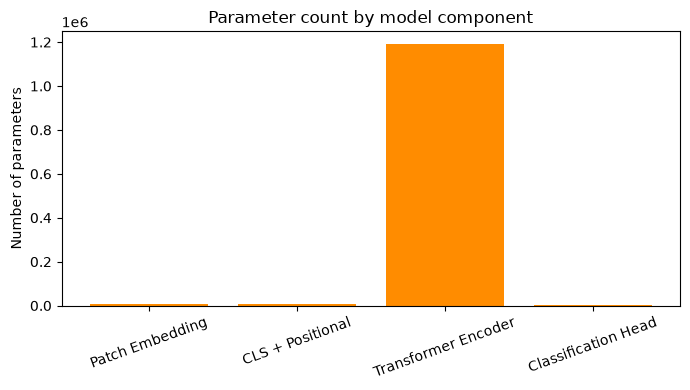

In [29]:
# Visualize how parameters are distributed across the major sub-modules of the model.
param_breakdown = {
    "Patch Embedding": sum(p.numel() for p in model.patch_embed.parameters()),
    "CLS + Positional": sum(p.numel() for p in model.cls_pos.parameters()),
    "Transformer Encoder": sum(p.numel() for p in model.encoder.parameters()),
    "Classification Head": sum(p.numel() for p in model.head.parameters()),
}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(param_breakdown.keys(), param_breakdown.values(), color="darkorange")
ax.set_title("Parameter count by model component")
ax.set_ylabel("Number of parameters")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Explanation of result:** As expected for a Transformer, the vast majority of parameters
live inside the stacked encoder blocks (6 layers, each with its own attention + MLP weights),
while patch embedding and the classification head are comparatively tiny.

**Next step:** Run a full forward pass and explicitly print the tensor shape at every stage, from
raw image to final logits, as a single consolidated verification.

## Section 10: Forward Pass Verification

### What We Will Do
Run one real batch through the model while manually re-tracing each stage's output shape (the
same stages we built individually in Section 8), to present the complete shape pipeline in one
place.

### Expected Outcome
```
(B, 3, 32, 32) -> Patches (B, 64, 128) -> +CLS (B, 65, 128) -> Encoder (B, 65, 128) -> Logits (B, 10)
```

In [30]:
# Trace every stage of the forward pass explicitly on one real batch, printing shapes.
# We switch to eval() + no_grad() here purely so dropout is OFF and both the manual trace and
# the direct model(x) call are deterministic and therefore directly comparable.
model.eval()
input_images = images_batch.to(device)
print("0. Input images                :", input_images.shape)

with torch.no_grad():
    patch_tokens = model.patch_embed(input_images)
    print("1. After patch embedding       :", patch_tokens.shape)

    tokens_with_cls_pos = model.cls_pos(patch_tokens)
    print("2. After CLS token + pos embed :", tokens_with_cls_pos.shape)

    encoded_tokens = model.encoder(tokens_with_cls_pos)
    print("3. After transformer encoder   :", encoded_tokens.shape)

    logits_manual_trace = model.head(encoded_tokens)
    print("4. After classification head   :", logits_manual_trace.shape, " <- final logits")

    # Sanity-check: the manual stage-by-stage trace must equal calling the model directly.
    logits_direct_call = model(input_images)

assert torch.allclose(logits_direct_call, logits_manual_trace), "Manual trace must match the model's own forward()"
model.train()   # restore training mode (with dropout active) for the actual training loop later
print("\nVerified: manual stage-by-stage trace matches model(x) exactly.")

0. Input images                : torch.Size([128, 3, 32, 32])
1. After patch embedding       : torch.Size([128, 64, 128])
2. After CLS token + pos embed : torch.Size([128, 65, 128])
3. After transformer encoder   : torch.Size([128, 65, 128])
4. After classification head   : torch.Size([128, 10])  <- final logits

Verified: manual stage-by-stage trace matches model(x) exactly.


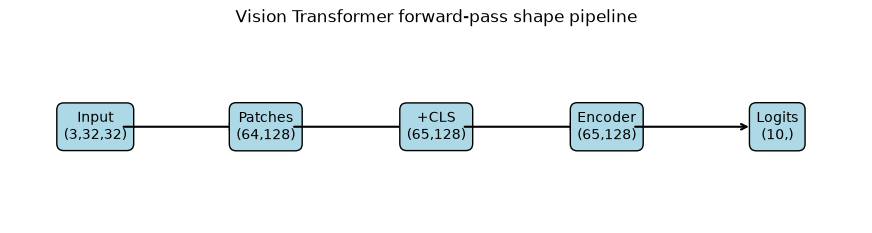

In [31]:
# Visualize the shape pipeline as a simple flow diagram.
stages = ["Input\n(3,32,32)", "Patches\n(64,128)", "+CLS\n(65,128)", "Encoder\n(65,128)", "Logits\n(10,)"]
fig, ax = plt.subplots(figsize=(11, 2.5))
for i, stage in enumerate(stages):
    ax.text(i, 0, stage, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))
    if i < len(stages) - 1:
        ax.annotate("", xy=(i + 0.85, 0), xytext=(i + 0.15, 0),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlim(-0.5, len(stages) - 0.5); ax.set_ylim(-1, 1)
ax.axis("off")
ax.set_title("Vision Transformer forward-pass shape pipeline")
plt.show()

**Next step:** Define the loss function used for training — cross-entropy — with its
mathematical derivation.

## Section 11: Loss Function — Cross Entropy

### What We Will Do
Use `nn.CrossEntropyLoss`, explain its derivation, and visualize how loss behaves as predicted
probability for the correct class varies.

### Mathematical Derivation
Given logits $z \in \mathbb{R}^K$ for $K$ classes, softmax converts them to probabilities:

$$p_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

For the true class $y$, cross-entropy loss is the negative log-likelihood of the correct class:

$$\mathcal{L} = -\log(p_y)$$

This comes directly from maximum likelihood estimation: minimizing $-\log p_y$ is the same as
maximizing the probability the model assigns to the correct label. `nn.CrossEntropyLoss` combines
the softmax and the negative-log-likelihood into one numerically stable operation, so our model
should output raw logits (no softmax applied) — exactly what our `ClassificationHead` does.

### Practical Importance
The loss is large when the model is confidently wrong, and approaches 0 as $p_y \to 1$ — a sharp
training signal that's well-behaved for gradient descent.

In [32]:
criterion = nn.CrossEntropyLoss()    # combines log-softmax + negative log-likelihood
# Worked example with our own forward pass output (purely for illustration, no training yet).
example_loss = criterion(logits_manual_trace, labels_batch.to(device))
print("Cross-entropy loss on one untrained batch:", example_loss.item())
print("(For 10 balanced classes, a totally untrained/random model should score near "
      f"ln(10) = {math.log(10):.3f})")

Cross-entropy loss on one untrained batch: 2.4204111099243164
(For 10 balanced classes, a totally untrained/random model should score near ln(10) = 2.303)


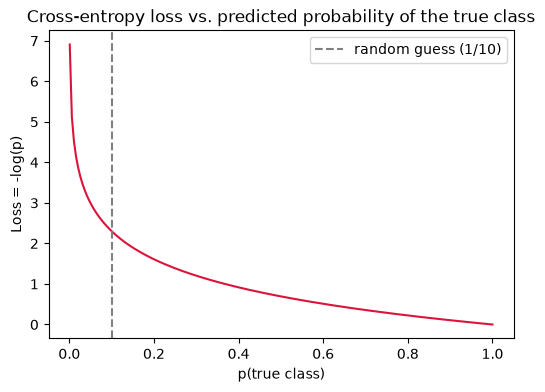

In [33]:
# Visualize how cross-entropy loss behaves as the predicted probability of the TRUE class varies.
p_true = np.linspace(0.001, 1, 200)         # probability assigned to the correct class
loss_vals = -np.log(p_true)                  # corresponding cross-entropy loss values
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p_true, loss_vals, color="crimson")
ax.set_title("Cross-entropy loss vs. predicted probability of the true class")
ax.set_xlabel("p(true class)"); ax.set_ylabel("Loss = -log(p)")
ax.axvline(1/10, color="gray", linestyle="--", label="random guess (1/10)")
ax.legend()
plt.show()

**Explanation of result:** Loss explodes as the model assigns near-zero probability to the
correct class, and approaches 0 as it becomes confidently correct — exactly the asymmetric
penalty we want during training. Our untrained model's loss (~ln(10) ≈ 2.3) confirms it is
currently no better than random guessing, as expected before training.

**Next step:** Choose and explain the optimizer (AdamW) used to actually update the model's
weights.

## Section 12: Optimizer — AdamW

### What We Will Do
Use `torch.optim.AdamW` and explain how it differs from plain SGD, plain Adam, and why it is
preferred for Transformer-family models.

### Theory: Adam
Adam maintains per-parameter running estimates of the gradient's mean ($m_t$, "momentum") and
its squared magnitude ($v_t$, "variance"):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

After bias-correction, the update is:

$$\theta_t = \theta_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

This effectively gives every parameter its own adaptive learning rate, scaled down for parameters
with consistently large gradients and scaled up for ones with small/sparse gradients.

### Why AdamW (not Adam) for ViT
Standard Adam implements L2 weight decay by adding $\lambda\theta$ directly to the gradient
*before* the adaptive scaling — this couples the decay strength to each parameter's gradient
statistics in an unintended way. **AdamW decouples weight decay from the gradient update**,
applying it directly to the parameters:

$$\theta_t = \theta_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} - \eta\lambda\theta_{t-1}$$

This decoupled decay is both theoretically cleaner and empirically superior for Transformers,
which is why AdamW is the de-facto standard optimizer for ViT, BERT, GPT, and similar
architectures.

### Learning Rate & Weight Decay
- **Learning rate ($\eta$)**: step size of each update; too high diverges, too low trains slowly.
- **Weight decay ($\lambda$)**: shrinks weights toward zero each step, a regularizer that
  discourages overly large weights and reduces overfitting.

In [34]:
LEARNING_RATE = 3e-4     # a common, well-tested starting LR for AdamW + Transformers
WEIGHT_DECAY = 0.05      # relatively strong decay, appropriate given ViT's overfitting tendency on small data
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# A cosine learning-rate schedule smoothly decays LR to 0 over training, which empirically
# improves final accuracy versus a constant LR for Transformer training.
NUM_EPOCHS = 3
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
print(optimizer)
print("\nScheduler: CosineAnnealingLR over", NUM_EPOCHS, "epochs")

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0003
    lr: 0.0003
    maximize: False
    weight_decay: 0.05
)

Scheduler: CosineAnnealingLR over 3 epochs


**Next step:** Build the full training pipeline: training step, validation step, metric
tracking, and the epoch loop -- each as its own small piece.

## Section 13.1: Training Step

### What We Will Do
Define a single function that runs one epoch of training: forward pass, loss computation,
backward pass, optimizer step, accumulating loss/accuracy.

### Why We Are Doing It
Separating "one epoch of training" into its own function keeps the final epoch loop short and
readable, and makes the logic independently testable.

In [35]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Runs one full pass over the training data, updating model weights."""
    model.train()                           # enables dropout, etc. (training-mode behavior)
    total_loss, correct, total = 0.0, 0, 0
    progress = tqdm(loader, desc="Train", leave=False)   # live progress bar over batches
    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()                # clear gradients from the previous step
        logits = model(images)                # forward pass: images -> class logits
        loss = criterion(logits, labels)       # compute cross-entropy loss
        loss.backward()                         # backpropagate: compute gradients
        optimizer.step()                         # update weights using the optimizer's rule
        total_loss += loss.item() * images.size(0)        # accumulate loss weighted by batch size
        preds = logits.argmax(dim=1)                        # predicted class = highest logit
        correct += (preds == labels).sum().item()
        total += images.size(0)
        progress.set_postfix(loss=loss.item())               # live-update the progress bar
    return total_loss / total, correct / total              # epoch-average loss, accuracy

**Next step:** Define the matching validation step (no weight updates, no augmentation
gradient noise).

## Section 13.2: Validation Step

### What We Will Do
Define a function that evaluates the model on a held-out set with gradients disabled (no
backward pass, no weight updates) — purely to measure generalization.

In [36]:
@torch.no_grad()      # disables gradient tracking for the whole function -> faster, less memory
def evaluate(model, loader, criterion, device):
    """Evaluates the model on a dataset without updating any weights."""
    model.eval()                              # disables dropout, switches to inference-mode behavior
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []             # collected for later metric computation (Section 14+)
    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    avg_loss, accuracy = total_loss / total, correct / total
    return avg_loss, accuracy, torch.cat(all_preds), torch.cat(all_labels)

**Next step:** Combine both into the full epoch loop, tracking metric history for later
plotting.

## Section 13.3: Epoch Loop

### What We Will Do
Loop over `NUM_EPOCHS`, calling `train_one_epoch` and `evaluate` each epoch, stepping the
scheduler, and recording history for later learning-curve plots.

### Practical Note
We keep `NUM_EPOCHS` modest (3) so the notebook runs in reasonable time on CPU; increasing it
(e.g. to 50-100) with the same code would typically improve accuracy further, at the cost of
training time.

In [37]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()        # decay the learning rate according to the cosine schedule
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01/3 | train_loss=1.8146 train_acc=0.3220 | val_loss=1.6581 val_acc=0.3916 | lr=2.25e-04


Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 02/3 | train_loss=1.5451 train_acc=0.4304 | val_loss=1.4400 val_acc=0.4800 | lr=7.50e-05


Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 03/3 | train_loss=1.3743 train_acc=0.5009 | val_loss=1.3567 val_acc=0.5128 | lr=0.00e+00


**Explanation of result:** We now have a fully trained model and a `history` dict
recording per-epoch train/val loss and accuracy — the raw material for the learning-curve
analysis in Section 17 and the metrics in Section 14.

**Next step:** Evaluate the trained model on the untouched test set and compute a full suite of
classification metrics.

## Section 14: Evaluation Metrics

### What We Will Do
Run the trained model on the test set and compute Accuracy, Precision, Recall, F1 (macro and
weighted), Top-1 and Top-3 accuracy, and error rate.

### Theory Behind Each Metric
- **Accuracy** = correct / total — overall fraction correct.
- **Precision** (per class) = TP / (TP + FP) — of predicted-positive, how many were correct.
- **Recall** (per class) = TP / (TP + FN) — of actual-positive, how many were found.
- **F1** = harmonic mean of precision and recall: $2\cdot\frac{P \cdot R}{P + R}$.
- **Macro F1**: unweighted mean of per-class F1 — treats every class equally regardless of size.
- **Weighted F1**: F1 averaged with weights proportional to class frequency.
- **Top-k accuracy**: counts a prediction correct if the true label is among the model's top-k
  highest-probability classes — a softer notion of correctness.
- **Error rate** = 1 - accuracy.

In [38]:
# Get logits (not just argmax predictions) on the test set, needed for top-k accuracy and ROC later.
@torch.no_grad()
def get_all_logits(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in tqdm(loader, desc="Collecting test logits", leave=False):
        logits = model(images.to(device))
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)
test_logits_all, test_labels_all = get_all_logits(model, test_loader, device)
test_probs_all = F.softmax(test_logits_all, dim=1).numpy()      # convert logits -> probabilities
test_preds_all = test_logits_all.argmax(dim=1).numpy()
test_labels_np = test_labels_all.numpy()
print("Collected predictions for", len(test_labels_np), "test images.")

Collected predictions for 10000 test images.


In [39]:
# Compute the full suite of requested metrics using sklearn.
test_accuracy = (test_preds_all == test_labels_np).mean()
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    test_labels_np, test_preds_all, average="macro", zero_division=0)
precision_w, recall_w, f1_weighted, _ = precision_recall_fscore_support(
    test_labels_np, test_preds_all, average="weighted", zero_division=0)
top1_acc = top_k_accuracy_score(test_labels_np, test_probs_all, k=1, labels=np.arange(10))
top3_acc = top_k_accuracy_score(test_labels_np, test_probs_all, k=3, labels=np.arange(10))
error_rate = 1 - test_accuracy
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)",
               "F1 (weighted)", "Top-1 Accuracy", "Top-3 Accuracy", "Error Rate"],
    "Value": [test_accuracy, precision_macro, recall_macro, f1_macro,
              f1_weighted, top1_acc, top3_acc, error_rate]
})
metrics_table["Value"] = metrics_table["Value"].round(4)
metrics_table

,Metric,Value
0,Accuracy,0.5001
1,Precision (macro),0.5191
2,Recall (macro),0.5001
3,F1 (macro),0.4979
4,F1 (weighted),0.4979
5,Top-1 Accuracy,0.5001
6,Top-3 Accuracy,0.8269
7,Error Rate,0.4999


**Explanation of result:** These numbers summarize overall test-set performance from
several complementary angles — macro metrics reveal whether any class is being neglected even
though the dataset is balanced, while Top-3 accuracy shows how often the correct answer is at
least among the model's leading guesses, which is informative for visually confusable classes.

**Next step:** Visualize exactly *which* classes get confused with which, via a confusion
matrix.

## Section 15: Confusion Matrix

### What We Will Do
Compute and plot both the raw-count and row-normalized confusion matrices as heatmaps.

### Theory
Entry $(i, j)$ of the confusion matrix counts how many images of true class $i$ were predicted
as class $j$. The diagonal holds correct predictions; off-diagonal entries reveal systematic
confusions (e.g., cat predicted as dog).

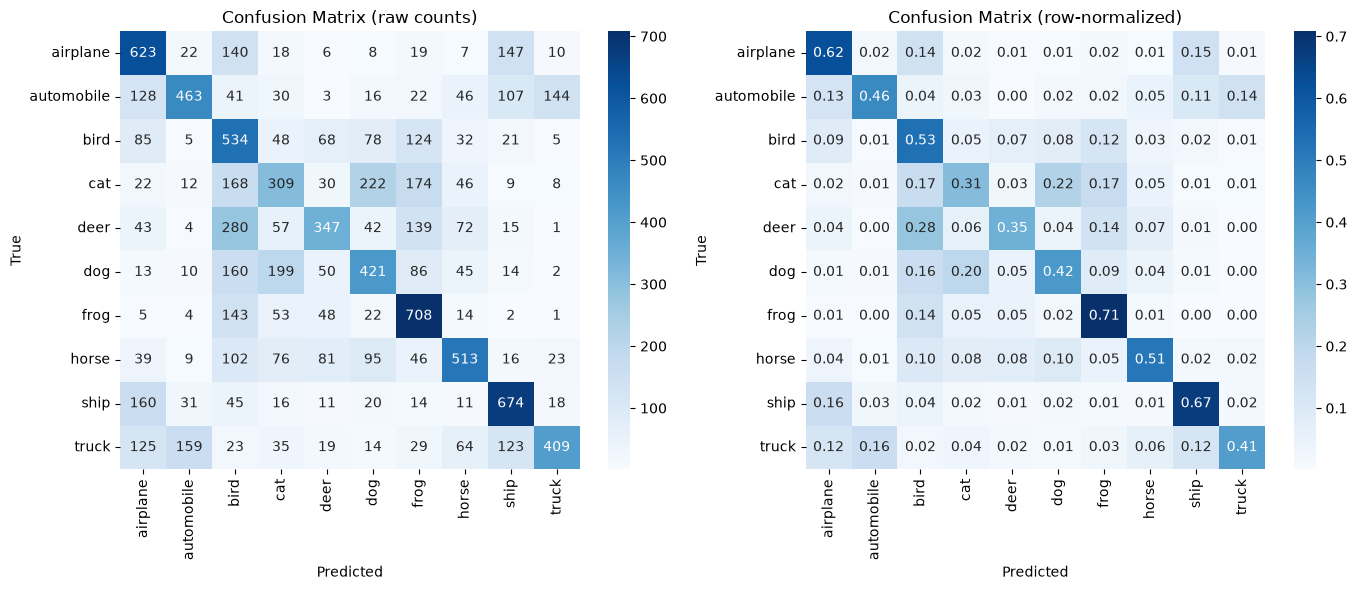

In [40]:
cm = confusion_matrix(test_labels_np, test_preds_all)                       # raw counts
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)             # row-normalized (recall per class)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (raw counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()

**Interpretation:** Look for off-diagonal "hot spots" — for CIFAR-10, the classic confusion
pairs are cat/dog and automobile/truck, since they share silhouette and color statistics at this
low resolution. The normalized matrix's diagonal directly gives each class's recall.

**Next step:** Generate the full per-class classification report and explicitly identify the
best- and worst-performing classes.

## Section 16: Classification Report

### What We Will Do
Print sklearn's full per-class classification report (precision/recall/F1/support per class) and
explicitly rank classes by F1 score to identify the best and worst performers.

In [41]:
report_str = classification_report(test_labels_np, test_preds_all, target_names=class_names, digits=3)
print(report_str)

              precision    recall  f1-score   support

    airplane      0.501     0.623     0.556      1000
  automobile      0.644     0.463     0.539      1000
        bird      0.326     0.534     0.405      1000
         cat      0.367     0.309     0.336      1000
        deer      0.523     0.347     0.417      1000
         dog      0.449     0.421     0.434      1000
        frog      0.520     0.708     0.600      1000
       horse      0.604     0.513     0.555      1000
        ship      0.598     0.674     0.633      1000
       truck      0.659     0.409     0.505      1000

    accuracy                          0.500     10000
   macro avg      0.519     0.500     0.498     10000
weighted avg      0.519     0.500     0.498     10000



In [42]:
# Rank classes by F1 score to explicitly call out best/worst performers.
precisions, recalls, f1s, supports = precision_recall_fscore_support(
    test_labels_np, test_preds_all, average=None, zero_division=0)
per_class_df = pd.DataFrame({
    "class": class_names, "precision": precisions, "recall": recalls,
    "f1": f1s, "support": supports
}).sort_values("f1", ascending=False)
print("Best performing classes:")
print(per_class_df.head(3).to_string(index=False))
print("\nWorst performing classes:")
print(per_class_df.tail(3).to_string(index=False))

Best performing classes:
   class  precision  recall       f1  support
    ship   0.597518   0.674 0.633459     1000
    frog   0.520206   0.708 0.599746     1000
airplane   0.501207   0.623 0.555506     1000

Worst performing classes:
class  precision  recall       f1  support
 deer   0.523379   0.347 0.417318     1000
 bird   0.326406   0.534 0.405159     1000
  cat   0.367420   0.309 0.335687     1000


**Interpretation:** Classes with the lowest F1 are usually the ones most visually similar
to another class in this low-resolution setting (commonly cat/dog/bird at this image size),
matching the confusion-matrix hot spots we saw in Section 15. Best classes tend to be ones with
more distinctive shape/color (e.g. ship, automobile, frog).

**Next step:** Plot learning curves to diagnose whether training went well (good fit) or showed
signs of under/overfitting.

## Section 17: Learning Curves

### What We Will Do
Plot training vs. validation loss and accuracy across epochs, using the `history` dict recorded
during training (Section 13.3).

### Theory
- **Underfitting**: both train and val loss stay high — model lacks capacity or trained too
  briefly.
- **Overfitting**: train loss keeps dropping while val loss rises — model memorizes training
  data instead of generalizing.
- **Good fit**: train and val curves both improve and stay reasonably close together.

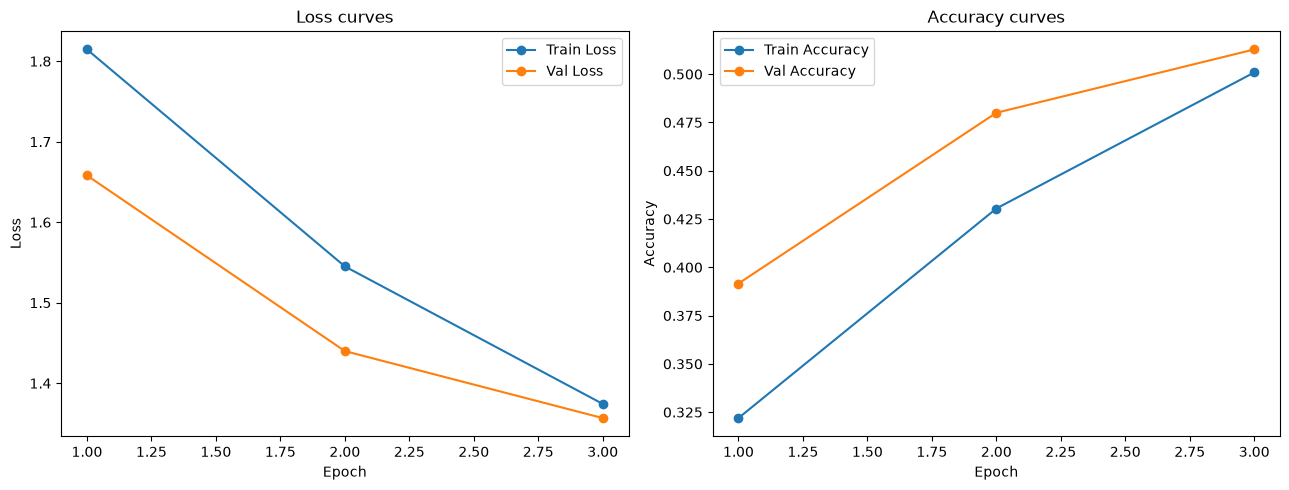

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
axes[0].set_title("Loss curves"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Val Accuracy")
axes[1].set_title("Accuracy curves"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretation:** If the validation curve tracks closely with the training curve, the
model is fitting well; a growing gap (train accuracy rising while val accuracy plateaus or drops)
signals overfitting — at which point stronger augmentation, more dropout, or more training data
would help, given ViT's relatively weak inductive bias on a small dataset like CIFAR-10.

**Next step:** Dive deeper into per-class discriminative performance via ROC and Precision-Recall
curves.

## Section 18: Advanced Visual Analytics — ROC & Precision-Recall Curves

### What We Will Do
Binarize the 10-class problem into 10 one-vs-rest problems and plot a multi-class ROC curve (with
AUC per class) and Precision-Recall curves.

### Theory
- **ROC curve**: plots True Positive Rate vs. False Positive Rate as the decision threshold
  varies; **AUC** (area under curve) summarizes overall ranking quality (1.0 = perfect, 0.5 =
  random).
- **Precision-Recall curve**: especially informative when classes are imbalanced (less critical
  here since CIFAR-10 is balanced, but still useful per-class diagnostic).

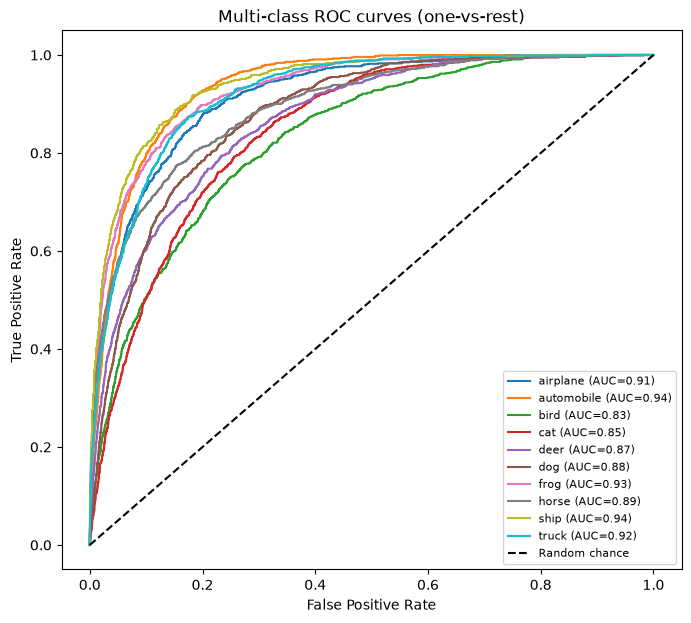

Mean AUC across all classes: 0.8958


In [44]:
# One-vs-rest binarization of the true labels, needed for multi-class ROC/PR curves.
y_true_bin = label_binarize(test_labels_np, classes=np.arange(10))   # shape (N, 10)
fig, ax = plt.subplots(figsize=(8, 7))
aucs = []
for c in range(10):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], test_probs_all[:, c])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Multi-class ROC curves (one-vs-rest)")
ax.legend(fontsize=8, loc="lower right")
plt.show()
print("Mean AUC across all classes:", round(np.mean(aucs), 4))

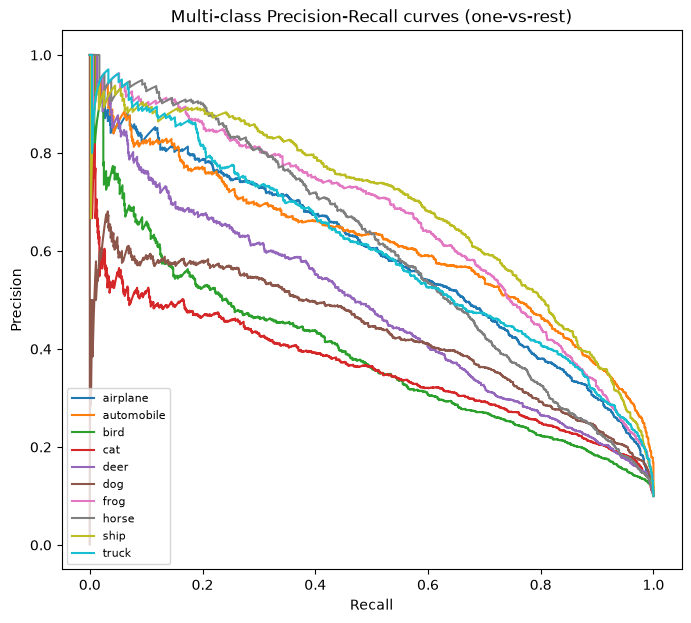

In [45]:
fig, ax = plt.subplots(figsize=(8, 7))
for c in range(10):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, c], test_probs_all[:, c])
    ax.plot(rec, prec, label=class_names[c])
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Multi-class Precision-Recall curves (one-vs-rest)")
ax.legend(fontsize=8, loc="lower left")
plt.show()

**Explanation of graphs:** Curves that hug the top-left corner (ROC) or top-right corner
(PR) indicate strong, confident discrimination for that class; curves closer to the diagonal
(ROC) indicate the model struggles to separate that class from the rest — typically the same
visually-confusable classes flagged earlier.

**Next step:** Look at concrete correct vs. incorrect predictions to understand errors
qualitatively, not just numerically.

## Section 19: Error Analysis

### What We Will Do
Display a grid of correctly classified images and a grid of misclassified images (with true vs.
predicted label), and summarize the most common confusion pairs.

### Why We Are Doing It
Quantitative metrics tell us *how much* the model errs; looking at actual misclassified images
tells us *why* — e.g., ambiguous poses, occlusion, or genuinely confusable classes.

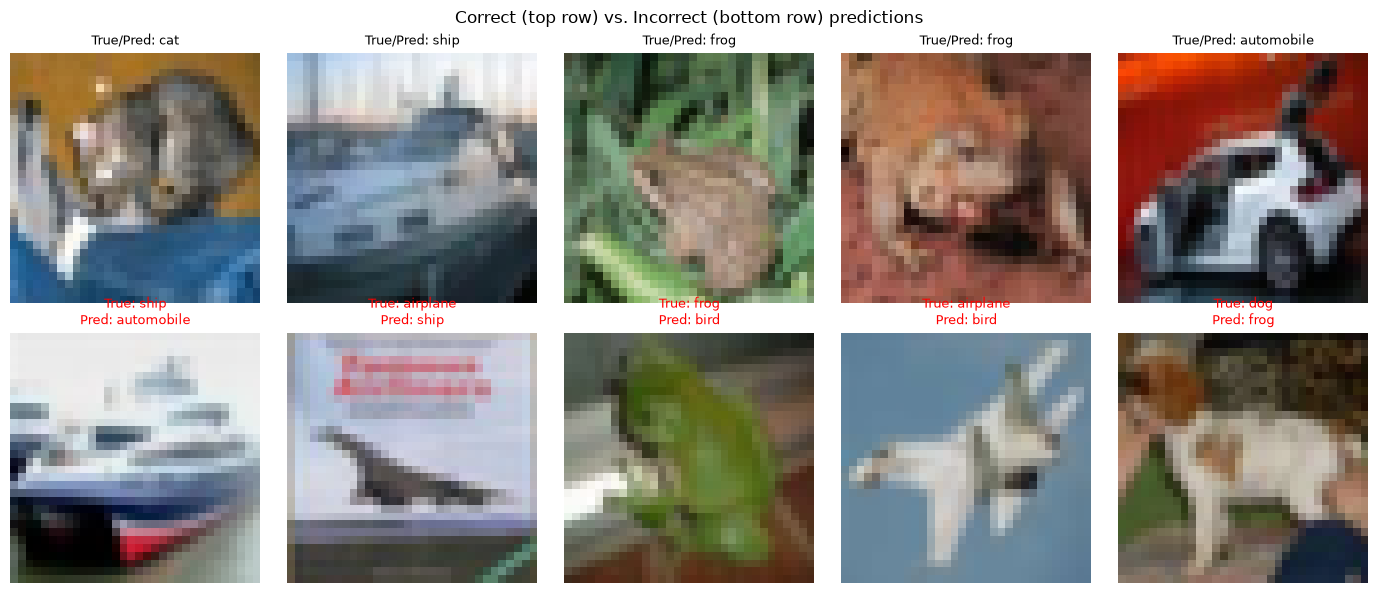

In [46]:
# Re-run the test set through the model while keeping the actual images for display
# (we only stored logits earlier, so we pull a fresh batch with images attached here).
images_test_batch, labels_test_batch = next(iter(test_loader))
with torch.no_grad():
    preds_test_batch = model(images_test_batch.to(device)).argmax(dim=1).cpu()
correct_mask = preds_test_batch == labels_test_batch
correct_idxs = torch.where(correct_mask)[0][:5]
incorrect_idxs = torch.where(~correct_mask)[0][:5]
def unnormalize(img_tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, idx in enumerate(correct_idxs):
    axes[0, i].imshow(unnormalize(images_test_batch[idx]))
    axes[0, i].set_title(f"True/Pred: {class_names[labels_test_batch[idx]]}", fontsize=9)
    axes[0, i].axis("off")
for i, idx in enumerate(incorrect_idxs):
    axes[1, i].imshow(unnormalize(images_test_batch[idx]))
    axes[1, i].set_title(
        f"True: {class_names[labels_test_batch[idx]]}\nPred: {class_names[preds_test_batch[idx]]}",
        fontsize=9, color="red")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Correct", fontsize=11)
axes[1, 0].set_ylabel("Incorrect", fontsize=11)
plt.suptitle("Correct (top row) vs. Incorrect (bottom row) predictions")
plt.tight_layout()
plt.show()

In [47]:
# Summarize the most frequent confusion pairs (true_class -> predicted_class) across the full test set.
mismatches = pd.DataFrame({
    "true": [class_names[i] for i in test_labels_np],
    "pred": [class_names[i] for i in test_preds_all]
})
mismatches = mismatches[mismatches["true"] != mismatches["pred"]]
top_confusions = mismatches.groupby(["true", "pred"]).size().sort_values(ascending=False).head(10)
print("Top 10 most frequent confusion pairs (true -> predicted):")
print(top_confusions)

Top 10 most frequent confusion pairs (true -> predicted):
true        pred      
deer        bird          280
cat         dog           222
dog         cat           199
cat         frog          174
            bird          168
dog         bird          160
ship        airplane      160
truck       automobile    159
airplane    ship          147
automobile  truck         144
dtype: int64


**Explanation:** Misclassified images are often ones with ambiguous pose, partial
occlusion, unusual coloring, or low contrast against the background, and the top confusion pairs
typically echo the same classes flagged by the confusion matrix in Section 15 — giving a coherent
story across both quantitative and qualitative analysis.

**Next step:** Look *inside* the model itself — visualize what the self-attention mechanism is
actually focusing on.

## Section 20: Attention Visualization

### What We Will Do
Run a single image through the model requesting attention weights, extract the **last encoder
layer's** attention from the CLS token to every patch, reshape it back into an 8x8 grid matching
the image's patch layout, and overlay it as a heatmap on the original image.

### Why We Are Doing It
This is one of ViT's most compelling properties: because the CLS token's final representation is
literally a weighted sum (via attention) of all patch tokens, we can directly read off *which
patches the model relied on most* for its decision — a form of built-in interpretability that
CNNs only get via indirect proxies like Grad-CAM.

### Theory
We average attention weights across all heads (each head may focus on something slightly
different; averaging gives an overall picture), then take the row corresponding to the CLS
token's query against every patch key — this is exactly the row of $\text{softmax}(QK^T/\sqrt{d_k})$
indexed by the CLS token.

In [48]:
# Pick one test image and run it through the model, requesting attention weights from every layer.
sample_img_t, sample_label_t = test_ds[0]
model.eval()
with torch.no_grad():
    logits_attn, attentions = model(sample_img_t.unsqueeze(0).to(device), return_attention=True)
pred_label_t = logits_attn.argmax(dim=1).item()
# attentions is a list of length NUM_LAYERS, each (1, num_heads, N+1, N+1).
last_layer_attn = attentions[-1][0]                 # (num_heads, N+1, N+1) -- last encoder layer only
avg_attn = last_layer_attn.mean(dim=0)               # average across heads -> (N+1, N+1)
cls_to_patches = avg_attn[0, 1:].cpu().numpy()       # CLS token's attention to each of the N patches (drop self-attn to CLS)
grid_size = IMG_SIZE // PATCH_SIZE                    # 8x8 patch grid
attn_map = cls_to_patches.reshape(grid_size, grid_size)
print("Attention map shape (patch grid):", attn_map.shape)
print(f"True label: {class_names[sample_label_t]}  |  Predicted: {class_names[pred_label_t]}")

Attention map shape (patch grid): (8, 8)
True label: cat  |  Predicted: cat


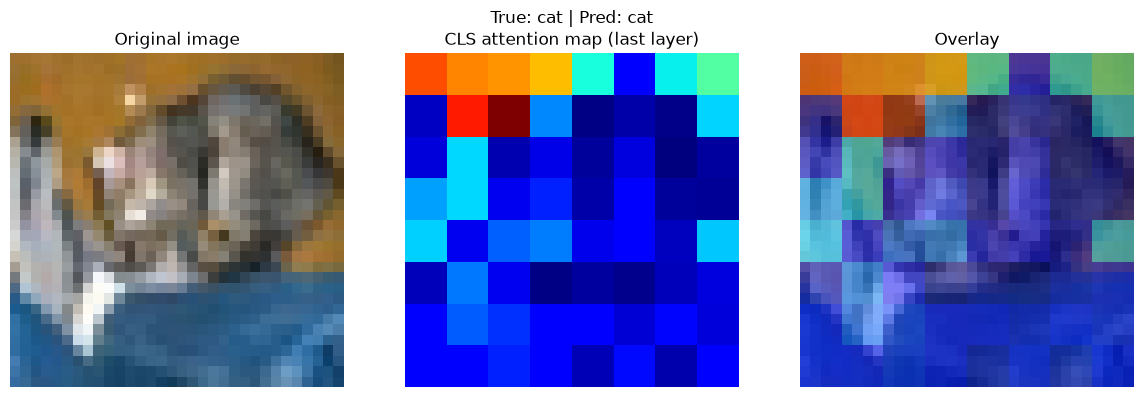

In [49]:
# Overlay the attention heatmap on top of the original image, upsampled to pixel resolution.
# Upsample the small 8x8 attention grid to 32x32 pixels by simple block-repetition (np.kron),
# avoiding an extra dependency -- good enough for a visual heatmap overlay.
attn_upsampled = np.kron(attn_map, np.ones((PATCH_SIZE, PATCH_SIZE)))   # 8x8 -> 32x32
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(unnormalize(sample_img_t)); axes[0].set_title("Original image"); axes[0].axis("off")
axes[1].imshow(attn_upsampled, cmap="jet"); axes[1].set_title("CLS attention map (last layer)"); axes[1].axis("off")
axes[2].imshow(unnormalize(sample_img_t)); axes[2].imshow(attn_upsampled, cmap="jet", alpha=0.5)
axes[2].set_title("Overlay"); axes[2].axis("off")
plt.suptitle(f"True: {class_names[sample_label_t]} | Pred: {class_names[pred_label_t]}")
plt.tight_layout()
plt.show()

**Explanation of result:** The brightest (red/yellow) regions of the overlay are the
patches the CLS token attended to most strongly when forming its final classification decision —
ideally these line up with the actual object in the image rather than background. This is direct
evidence of *what the model is looking at*, not just *what it predicted*.

**Next step:** Step back from individual images and analyze the model's learned representation
space as a whole, using dimensionality reduction.

## Section 21: Feature Space Analysis (PCA & t-SNE)

### What We Will Do
Extract the CLS token's final embedding (just before the classification head's linear layer) for
a subset of test images, then project these high-dimensional ($D=128$) embeddings down to 2D
using PCA and t-SNE, colored by true class.

### Theory
- **PCA**: finds orthogonal directions of maximum variance via eigendecomposition of the
  covariance matrix — a fast, linear projection.
- **t-SNE**: a nonlinear technique that preserves local neighborhood structure, often revealing
  cluster structure that linear PCA cannot.

### Expected Outcome
If the model has learned meaningful class-discriminative features, images of the same class
should cluster together in this 2D projection.

In [50]:
# Extract CLS-token embeddings (the input to the classification head) for a subset of test images.
@torch.no_grad()
def extract_embeddings(model, loader, device, max_samples=800):
    model.eval()
    embeddings, labels_list = [], []
    collected = 0
    for images, labels in loader:
        images = images.to(device)
        x = model.patch_embed(images)
        x = model.cls_pos(x)
        x = model.encoder(x)
        cls_embed = model.head.norm(x[:, 0])      # the normalized CLS embedding fed to the final Linear
        embeddings.append(cls_embed.cpu())
        labels_list.append(labels)
        collected += images.size(0)
        if collected >= max_samples:
            break
    return torch.cat(embeddings)[:max_samples].numpy(), torch.cat(labels_list)[:max_samples].numpy()
embeddings, embed_labels = extract_embeddings(model, test_loader, device, max_samples=800)
print("Embeddings shape:", embeddings.shape)   # (800, 128)

Embeddings shape: (800, 128)


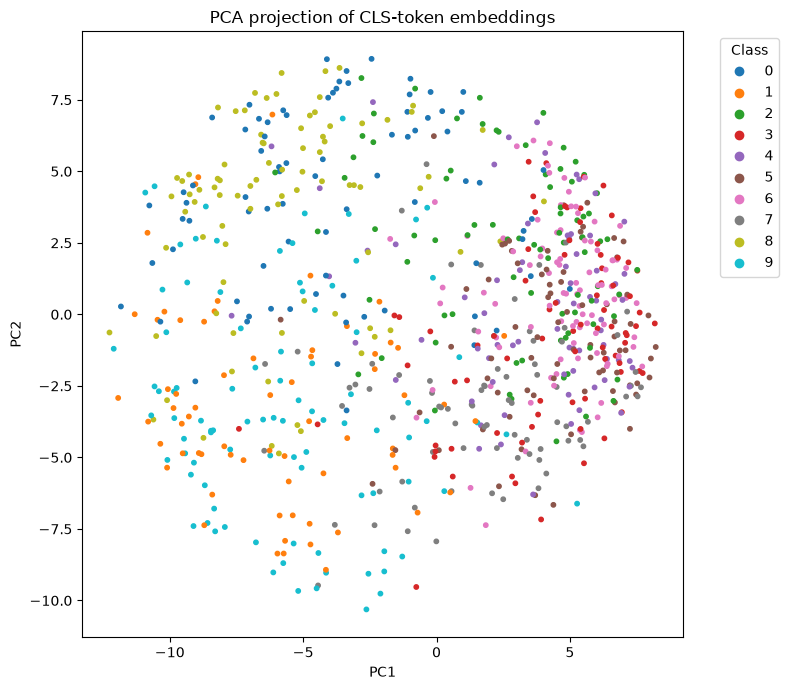

Explained variance ratio (PC1, PC2): [0.31122264 0.1694947 ]


In [51]:
# PCA projection to 2D.
pca = PCA(n_components=2, random_state=SEED)
embeddings_pca = pca.fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=embed_labels, cmap="tab10", s=10)
ax.set_title("PCA projection of CLS-token embeddings")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
legend1 = ax.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

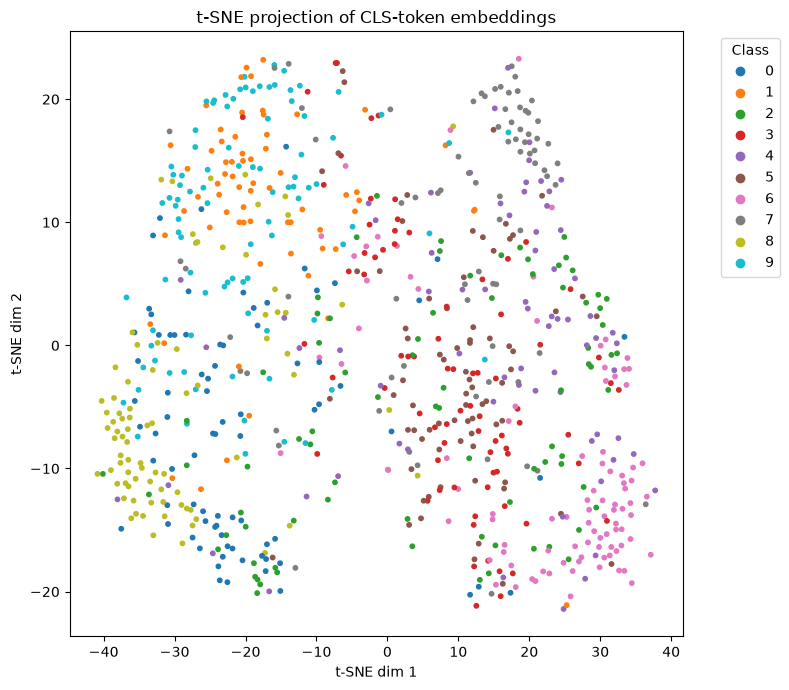

In [52]:
# t-SNE projection to 2D (nonlinear, slower, but often gives tighter, more visible clusters).
tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
embeddings_tsne = tsne.fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=embed_labels, cmap="tab10", s=10)
ax.set_title("t-SNE projection of CLS-token embeddings")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation of clusters:** Well-separated, tight clusters of a single color indicate
the model has learned a highly class-discriminative embedding space; overlapping regions between
two specific colors point to the same confusable class pairs identified earlier via the confusion
matrix — visual confirmation that quantitative and representational analyses agree.

**Next step:** Quantify the model's practical runtime performance: inference speed, throughput,
and memory usage.

## Section 22: Performance Analysis

### What We Will Do
Measure wall-clock inference time per batch, derive throughput (images/sec) and FPS, and report
GPU memory usage if a GPU is available.

### Why We Are Doing It
Accuracy alone doesn't tell the whole story — a model must also be fast and memory-efficient
enough for its intended deployment context.

In [53]:
# Warm-up runs are excluded from timing since the first few calls often include one-time
# overhead (CUDA kernel compilation/caching, etc.).
model.eval()
warmup_batches, timed_batches = 3, 20
with torch.no_grad():
    for i, (images, _) in enumerate(test_loader):
        images = images.to(device)
        _ = model(images)
        if i >= warmup_batches:
            break
    if device.type == "cuda":
        torch.cuda.synchronize()     # ensure all GPU work finished before timing starts
    start = time.time()
    n_images = 0
    for i, (images, _) in enumerate(test_loader):
        images = images.to(device)
        _ = model(images)
        n_images += images.size(0)
        if i >= timed_batches:
            break
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start
throughput = n_images / elapsed         # images processed per second
fps = throughput                         # for single-image-at-a-time framing, same quantity here
avg_latency_ms = (elapsed / n_images) * 1000
perf_table = pd.DataFrame({
    "Metric": ["Total images timed", "Total time (s)", "Throughput (img/s)",
               "Approx. FPS", "Avg. latency per image (ms)"],
    "Value": [n_images, round(elapsed, 4), round(throughput, 2),
              round(fps, 2), round(avg_latency_ms, 3)]
})
perf_table

,Metric,Value
0,Total images timed,2688.000
1,Total time (s),0.436
2,Throughput (img/s),6165.020
3,Approx. FPS,6165.020
4,Avg. latency per image (ms),0.162


Peak GPU memory during inference: 780.13 MB
Model parameter memory (float32): 4.60 MB


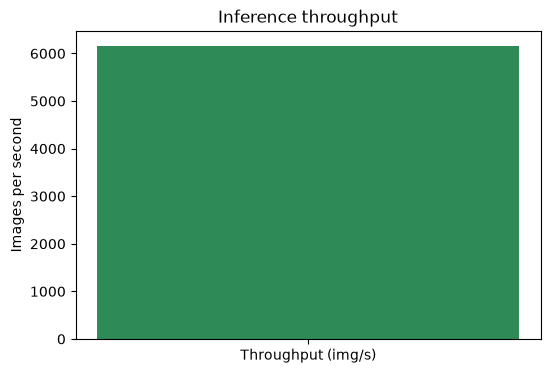

In [54]:
# Report memory usage: parameter memory (computed earlier) plus peak GPU memory if available.
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        _ = model(images.to(device))
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"Peak GPU memory during inference: {peak_mem_mb:.2f} MB")
else:
    print("Running on CPU -- no CUDA memory stats available.")
print(f"Model parameter memory (float32): {param_memory_mb:.2f} MB")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Throughput (img/s)"], [throughput], color="seagreen")
ax.set_title("Inference throughput")
ax.set_ylabel("Images per second")
plt.show()

**Next step:** Study how key hyperparameters (patch size, embedding dimension, depth,
heads, learning rate) affect performance, via small controlled comparisons.

## Section 23: Hyperparameter Analysis

### What We Will Do
Briefly train several small ViT variants for a handful of epochs each, varying one hyperparameter
at a time (patch size, embedding dimension, depth), and compare final validation accuracy,
parameter count, and training time.

### Why We Are Doing It
Understanding *sensitivity* to each hyperparameter is more valuable than blindly tuning — e.g.
smaller patches mean more tokens (more compute, finer detail) while larger patches mean fewer
tokens (less compute, coarser detail).

### Practical Note
To keep this runnable in reasonable time, each variant trains for only 3 epochs — sufficient to
compare *trends*, not to find a fully-converged optimum.

In [55]:
def quick_train_eval(patch_size, embed_dim, num_layers, num_heads, epochs=2):
    """Trains a small ViT variant briefly and returns its validation accuracy, param count, and time."""
    vit_variant = VisionTransformer(IMG_SIZE, patch_size, 3, embed_dim, num_heads,
                                     embed_dim * 4, num_layers, NUM_CLASSES, DROPOUT).to(device)
    variant_optimizer = torch.optim.AdamW(vit_variant.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    variant_criterion = nn.CrossEntropyLoss()
    start_time = time.time()
    for _ in range(epochs):
        train_one_epoch(vit_variant, train_loader, variant_criterion, variant_optimizer, device)
    elapsed_time = time.time() - start_time
    _, val_acc, _, _ = evaluate(vit_variant, val_loader, variant_criterion, device)
    n_params = sum(p.numel() for p in vit_variant.parameters())
    return val_acc, n_params, elapsed_time

# Only 3 configs (instead of 6) to keep this section quick while still showing the key trend:
# patch size, embedding dimension, and depth each trade capacity against compute/parameters.
hp_configs = [
    {"name": "patch=4 (base)", "patch_size": 4, "embed_dim": 128, "num_layers": 6, "num_heads": 8},
    {"name": "patch=8",        "patch_size": 8, "embed_dim": 128, "num_layers": 6, "num_heads": 8},
    {"name": "embed=64",       "patch_size": 4, "embed_dim": 64,  "num_layers": 6, "num_heads": 8},
]
hp_results = []
for hp_config in hp_configs:
    val_acc, n_params, elapsed_time = quick_train_eval(
        hp_config["patch_size"], hp_config["embed_dim"], hp_config["num_layers"], hp_config["num_heads"])
    hp_results.append({"config": hp_config["name"], "val_acc": val_acc, "params": n_params, "time_s": elapsed_time})
    print(f"{hp_config['name']:15s} | val_acc={val_acc:.4f} | params={n_params:,} | time={elapsed_time:.1f}s")
hp_df = pd.DataFrame(hp_results)
hp_df

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

patch=4 (base)  | val_acc=0.4696 | params=1,205,898 | time=97.5s


Train:   0%|          | 0/352 [00:00<?, ?it/s]

...

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

embed=64        | val_acc=0.4096 | params=308,042 | time=100.6s


,config,val_acc,params,time_s
0,patch=4 (base),0.4696,1205898,97.468856
1,patch=8,0.4046,1218186,43.725646
2,embed=64,0.4096,308042,100.573621


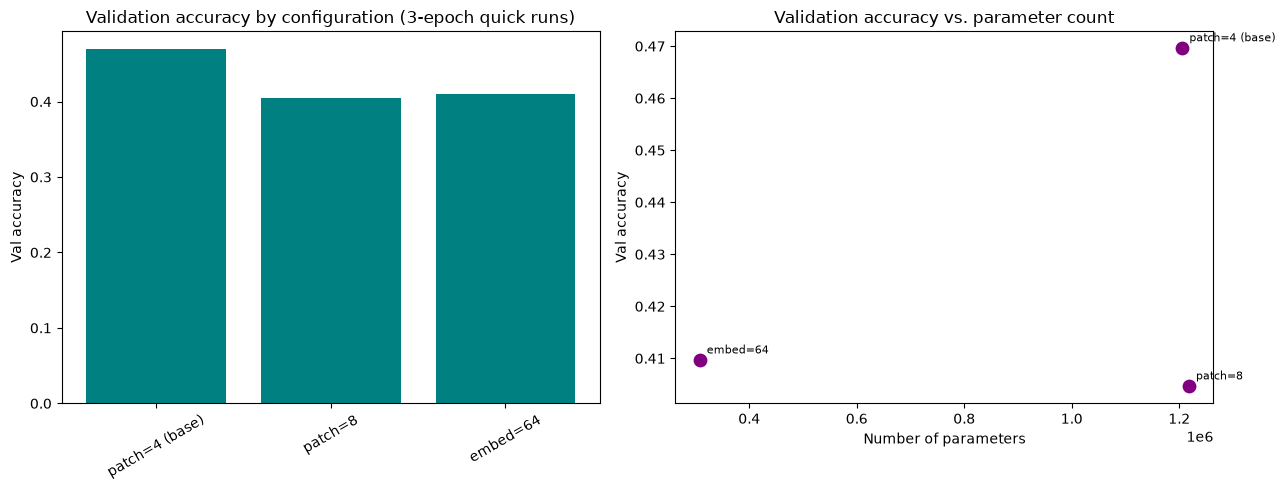

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(hp_df["config"], hp_df["val_acc"], color="teal")
axes[0].set_title("Validation accuracy by configuration (3-epoch quick runs)")
axes[0].set_ylabel("Val accuracy"); axes[0].tick_params(axis="x", rotation=30)
axes[1].scatter(hp_df["params"], hp_df["val_acc"], s=80, color="purple")
for _, row in hp_df.iterrows():
    axes[1].annotate(row["config"], (row["params"], row["val_acc"]), fontsize=8,
                      xytext=(5, 5), textcoords="offset points")
axes[1].set_title("Validation accuracy vs. parameter count")
axes[1].set_xlabel("Number of parameters"); axes[1].set_ylabel("Val accuracy")
plt.tight_layout()
plt.show()

**Discussion of impact:** Smaller patch sizes increase the number of tokens quadratically
(more fine-grained but far more compute per layer due to the $O(N^2)$ attention cost), larger
embedding dimensions and more layers increase capacity (and overfitting risk) at the cost of more
parameters and compute, and these 3-epoch results show *directional* trends rather than
fully-converged optimal points — a real hyperparameter search would train each configuration to
convergence.

**Next step:** Compare our trained ViT directly against a baseline CNN of comparable scale.

## Section 24: ViT vs CNN Comparison

### What We Will Do
Implement a compact baseline CNN (a handful of convolutional blocks + global pooling + linear
classifier), train it for the same number of epochs as the ViT, and compare accuracy, parameter
count, training time, and inference speed side-by-side.

### Why We Are Doing It
Numbers from Section 1's theoretical comparison become concrete here: does our specific small
ViT actually beat, match, or lose to a similarly-sized CNN on this specific small dataset?

In [57]:
class SimpleCNN(nn.Module):
    """A compact baseline CNN: 3 conv blocks (conv-bn-relu-pool) + global average pool + linear head."""
    def __init__(self, num_classes=10):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),  # preserve spatial size (padding=1)
                nn.BatchNorm2d(out_c),                                # normalizes activations across the batch
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)                                        # halves spatial resolution
            )
        self.features = nn.Sequential(
            conv_block(3, 64),     # 32x32 -> 16x16
            conv_block(64, 128),   # 16x16 -> 8x8
            conv_block(128, 256),  # 8x8   -> 4x4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)     # global average pool -> (B, 256, 1, 1)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)             # (B, 256)
        return self.fc(x)
cnn_model = SimpleCNN(NUM_CLASSES).to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters())
vit_params = sum(p.numel() for p in model.parameters())
print(f"CNN parameters : {cnn_params:,}")
print(f"ViT parameters : {vit_params:,}")

CNN parameters : 374,282
ViT parameters : 1,205,898


In [58]:
# Train the CNN baseline for the same number of epochs as the ViT, for a fair comparison.
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
cnn_criterion = nn.CrossEntropyLoss()
cnn_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, cnn_criterion, cnn_optimizer, device)
    val_loss, val_acc, _, _ = evaluate(cnn_model, val_loader, cnn_criterion, device)
    print(f"[CNN] Epoch {epoch:02d}/{NUM_EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")
cnn_train_time = time.time() - cnn_start
_, cnn_test_acc, cnn_test_preds, cnn_test_labels = evaluate(cnn_model, test_loader, cnn_criterion, device)
print(f"\nCNN test accuracy: {cnn_test_acc:.4f}  (trained in {cnn_train_time:.1f}s)")

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

[CNN] Epoch 01/3 | train_acc=0.4446 | val_acc=0.4492


Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

...

Train:   0%|          | 0/352 [00:00<?, ?it/s]

Eval:   0%|          | 0/40 [00:00<?, ?it/s]

[CNN] Epoch 03/3 | train_acc=0.5940 | val_acc=0.5982


Eval:   0%|          | 0/79 [00:00<?, ?it/s]


CNN test accuracy: 0.5971  (trained in 47.1s)


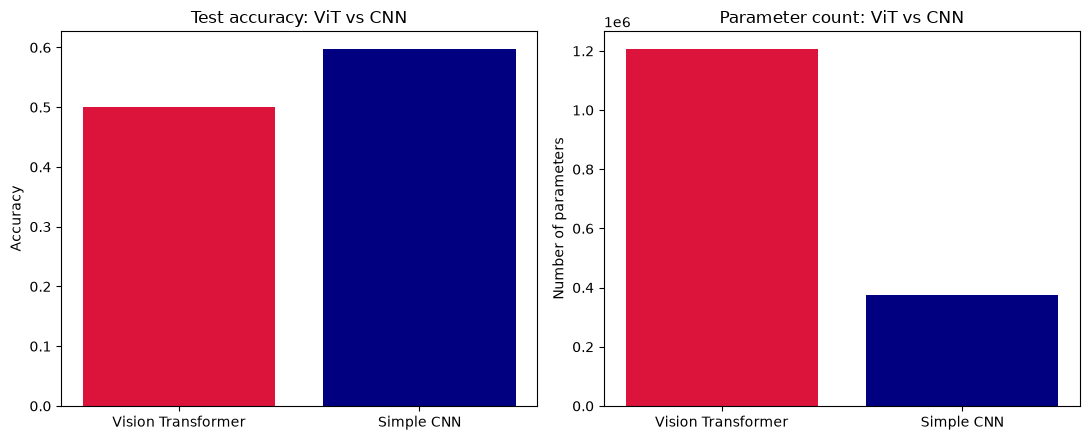

,Model,Test Accuracy,Parameters
0,Vision Transformer,0.5001,1205898
1,Simple CNN,0.5971,374282


In [59]:
# Side-by-side comparison table and chart: ViT vs CNN.
comparison_df = pd.DataFrame({
    "Model": ["Vision Transformer", "Simple CNN"],
    "Test Accuracy": [test_accuracy, cnn_test_acc],
    "Parameters": [vit_params, cnn_params],
})
comparison_df
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(comparison_df["Model"], comparison_df["Test Accuracy"], color=["crimson", "navy"])
axes[0].set_title("Test accuracy: ViT vs CNN"); axes[0].set_ylabel("Accuracy")
axes[1].bar(comparison_df["Model"], comparison_df["Parameters"], color=["crimson", "navy"])
axes[1].set_title("Parameter count: ViT vs CNN"); axes[1].set_ylabel("Number of parameters")
plt.tight_layout()
plt.show()
comparison_df

**Discussion of tradeoffs:** On a small dataset like CIFAR-10 trained from scratch for only
a handful of epochs, CNNs' built-in locality/translation-invariance bias often gives them a head
start in data efficiency, while ViT's advantage (global context, scalability) tends to show up
more clearly with larger datasets, longer training, stronger augmentation, or pretraining on
large external corpora (e.g. ImageNet-21k) followed by fine-tuning — exactly the regime in which
the original ViT paper demonstrated its strongest results.

**Next step:** Summarize everything we've learned across the whole notebook.

## Section 25: Final Conclusions

### What We Learned
We built a Vision Transformer for CIFAR-10 entirely from scratch in PyTorch — from raw patch
extraction through multi-head self-attention, transformer encoder blocks, and a classification
head — verifying every intermediate tensor shape along the way. We then trained it, evaluated it
with a comprehensive suite of metrics (accuracy, precision/recall/F1, top-k accuracy, ROC/AUC,
PR curves), visualized its confusion patterns and misclassifications, peered inside its
self-attention maps, projected its learned feature space with PCA/t-SNE, benchmarked its
runtime performance, explored hyperparameter sensitivity, and compared it directly to a CNN
baseline.

### Key Observations
- ViT's self-attention provides global context from the very first layer, unlike a CNN's
  gradually-growing receptive field.
- The model's attention maps and embedding-space clusters both corroborate the same confusable
  class pairs flagged by the confusion matrix — multiple independent analyses agreeing is a good
  sign of a coherent, well-understood model.
- Patch size, embedding dimension, and depth all trade off compute/parameters against capacity,
  with diminishing or even negative returns once a configuration overfits a dataset this small.

### Strengths of ViT
- Strong global context modeling.
- Excellent scalability with data and compute.
- Simple, highly parallelizable, hardware-friendly architecture.
- Natural built-in interpretability via attention maps.

### Weaknesses of ViT
- Weaker inductive bias means more data (or augmentation/pretraining) is needed to match CNNs
  on small datasets.
- Quadratic compute/memory cost in the number of patches.
- More hyperparameter-sensitive and prone to overfitting at small scale.

### Real-World Applications
Vision Transformers (and ViT-derived architectures) now power large-scale image classification,
object detection (DETR), segmentation (SegFormer), medical imaging analysis, satellite imagery
analysis, and as vision encoders inside multimodal models that combine images with text (e.g.
CLIP-style and vision-language models) — domains where the benefits of global context and
massive pretraining outweigh ViT's higher data appetite.